# Rossmann Store Sales Forecasting

## Project Overview

The objective of this project is to develop an end-to-end machine learning solution for forecasting daily sales across multiple Rossmann retail stores. Accurate sales forecasting enables businesses to optimize inventory, staffing, promotions, and financial planning.

This project follows a structured data science workflow, including:

- Data Loading
- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Machine Learning
- Deep Learning
- Model Explainability
- MLflow Experiment Tracking
- Streamlit Deployment

The solution is designed using modular, production-oriented coding practices to ensure reproducibility and scalability.

# Project Objective

The objective of this project is to analyze Rossmann Store Sales data, identify the key factors influencing sales performance, and build a machine learning model capable of accurately predicting future sales. The insights generated aim to support data-driven business decisions related to promotions, inventory management, and store operations.

In [10]:
import os
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


In [11]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

logger = logging.getLogger()

logger.info("Logger initialized successfully.")

2026-08-13 11:00:25,093 | INFO | Logger initialized successfully.


## Project Path

In [12]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data"

TRAIN_PATH = DATA_PATH / "train.csv"
TEST_PATH = DATA_PATH / "test.csv"
STORE_PATH = DATA_PATH / "store.csv"
SUBMISSION_PATH = DATA_PATH / "sample_submission.csv"

logger.info("Project paths configured.")

2026-08-13 11:00:25,099 | INFO | Project paths configured.


## Load Dataset

In [13]:
train_df = pd.read_csv('/Users/Swati/workspace/Project_6/train.csv')
test_df = pd.read_csv('/Users/Swati/workspace/Project_6/test.csv')
store_df = pd.read_csv('/Users/Swati/workspace/Project_6/store.csv')
submission_df = pd.read_csv('/Users/Swati/workspace/Project_6/sample_submission.csv')

logger.info("Datasets loaded successfully.")

print(f"Train Shape       : {train_df.shape}")
print(f"Test Shape        : {test_df.shape}")
print(f"Store Shape       : {store_df.shape}")
print(f"Submission Shape  : {submission_df.shape}")

/var/folders/w6/l_tsk15x7qs3fdjfr40clyx40000gp/T/ipykernel_70807/1989475806.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv('/Users/Swati/workspace/Project_6/train.csv')
2026-08-13 11:00:25,425 | INFO | Datasets loaded successfully.


Train Shape       : (1017209, 9)
Test Shape        : (41088, 8)
Store Shape       : (1115, 10)
Submission Shape  : (41088, 2)


## Preview Dataset

In [14]:
display(train_df.head())

display(test_df.head())

display(store_df.head())

display(submission_df.head())

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.00,1,0,0
1,2,3,4,2015-09-17,1.00,1,0,0
2,3,7,4,2015-09-17,1.00,1,0,0
3,4,8,4,2015-09-17,1.00,1,0,0
4,5,9,4,2015-09-17,1.00,1,0,0


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.00,9.00,2008.00,0,NaN,NaN,NaN
1,2,a,a,570.00,11.00,2007.00,1,13.00,2010.00,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.00,12.00,2006.00,1,14.00,2011.00,"Jan,Apr,Jul,Oct"
3,4,c,c,620.00,9.00,2009.00,0,NaN,NaN,NaN
4,5,a,a,29910.00,4.00,2015.00,0,NaN,NaN,NaN


,Id,Sales
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


## Key Observations: Dataset Preview

The initial preview of the datasets provides a quick understanding of their structure and contents before performing detailed analysis.

### Observations

- **Train Dataset:** Contains historical sales records along with customer count and store-related information. This dataset will be used to train the forecasting models.
- **Test Dataset:** Contains similar features as the training dataset but does not include the target variable (`Sales`), which needs to be predicted.
- **Store Dataset:** Provides additional information about each store, including store type, assortment, competition details, and promotional information. This dataset will later be merged with both training and testing datasets.
- **Sample Submission Dataset:** Demonstrates the required submission format containing the `Id` and predicted `Sales` columns.

### Initial Understanding

The datasets appear to be well-structured and share the common `Store` identifier, which will be used to combine transactional data with store-level information for feature enrichment.

The next step is to perform a detailed assessment of data types, missing values, and overall data quality before preprocessing.

## Dataset Information

In [15]:
datasets = {
    "Train": train_df,
    "Test": test_df,
    "Store": store_df,
    "Submission": submission_df
}

for name, df in datasets.items():
    print("=" * 70)
    print(f"{name} Dataset")
    print("=" * 70)

    print("\nShape:", df.shape)

    display(df.info())

    display(df.describe(include="all"))

Train Dataset

Shape: (1017209, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


None

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
count,1017209.00,1017209.00,1017209,1017209.00,1017209.00,1017209.00,1017209.00,1017209,1017209.00
unique,NaN,NaN,942,NaN,NaN,NaN,NaN,5,NaN
top,NaN,NaN,2015-07-31,NaN,NaN,NaN,NaN,0,NaN
freq,NaN,NaN,1115,NaN,NaN,NaN,NaN,855087,NaN
mean,558.43,4.00,NaN,5773.82,633.15,0.83,0.38,NaN,0.18
std,321.91,2.00,NaN,3849.93,464.41,0.38,0.49,NaN,0.38
min,1.00,1.00,NaN,0.00,0.00,0.00,0.00,NaN,0.00
25%,280.00,2.00,NaN,3727.00,405.00,1.00,0.00,NaN,0.00
50%,558.00,4.00,NaN,5744.00,609.00,1.00,0.00,NaN,0.00
75%,838.00,6.00,NaN,7856.00,837.00,1.00,1.00,NaN,0.00


Test Dataset

Shape: (41088, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             41088 non-null  int64  
 1   Store          41088 non-null  int64  
 2   DayOfWeek      41088 non-null  int64  
 3   Date           41088 non-null  object 
 4   Open           41077 non-null  float64
 5   Promo          41088 non-null  int64  
 6   StateHoliday   41088 non-null  object 
 7   SchoolHoliday  41088 non-null  int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 2.5+ MB


None

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
count,41088.00,41088.00,41088.00,41088,41077.00,41088.00,41088,41088.00
unique,NaN,NaN,NaN,48,NaN,NaN,2,NaN
top,NaN,NaN,NaN,2015-09-17,NaN,NaN,0,NaN
freq,NaN,NaN,NaN,856,NaN,NaN,40908,NaN
mean,20544.50,555.90,3.98,NaN,0.85,0.40,NaN,0.44
std,11861.23,320.27,2.02,NaN,0.35,0.49,NaN,0.50
min,1.00,1.00,1.00,NaN,0.00,0.00,NaN,0.00
25%,10272.75,279.75,2.00,NaN,1.00,0.00,NaN,0.00
50%,20544.50,553.50,4.00,NaN,1.00,0.00,NaN,0.00
75%,30816.25,832.25,6.00,NaN,1.00,1.00,NaN,1.00


Store Dataset

Shape: (1115, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


None

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
count,1115.00,1115,1115,1112.00,761.00,761.00,1115.00,571.00,571.00,571
unique,NaN,4,3,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,a,a,NaN,NaN,NaN,NaN,NaN,NaN,"Jan,Apr,Jul,Oct"
freq,NaN,602,593,NaN,NaN,NaN,NaN,NaN,NaN,335
mean,558.00,NaN,NaN,5404.90,7.22,2008.67,0.51,23.60,2011.76,NaN
std,322.02,NaN,NaN,7663.17,3.21,6.20,0.50,14.14,1.67,NaN
min,1.00,NaN,NaN,20.00,1.00,1900.00,0.00,1.00,2009.00,NaN
25%,279.50,NaN,NaN,717.50,4.00,2006.00,0.00,13.00,2011.00,NaN
50%,558.00,NaN,NaN,2325.00,8.00,2010.00,1.00,22.00,2012.00,NaN
75%,836.50,NaN,NaN,6882.50,10.00,2013.00,1.00,37.00,2013.00,NaN


Submission Dataset

Shape: (41088, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Id      41088 non-null  int64
 1   Sales   41088 non-null  int64
dtypes: int64(2)
memory usage: 642.1 KB


None

,Id,Sales
count,41088.00,41088.00
mean,20544.50,0.00
std,11861.23,0.00
min,1.00,0.00
25%,10272.75,0.00
50%,20544.50,0.00
75%,30816.25,0.00
max,41088.00,0.00


## Key Observations: Dataset Information

The dataset information provides an overview of the dimensions, data types, and statistical properties of each dataset.

### Observations

- The training dataset contains historical transactional records that will be used to build the predictive model.
- The testing dataset has a similar structure but excludes the target variable (`Sales`).
- The store dataset contains descriptive attributes that can significantly improve prediction performance after merging.
- Numerical features exhibit varying ranges, indicating that scaling may be required for certain machine learning algorithms.
- Several categorical variables are stored as object data types and will require appropriate encoding during preprocessing.
- Date columns are currently stored as strings and will be converted to datetime format for extracting useful temporal features.

### Conclusion

Understanding the structure and characteristics of each dataset is an essential first step before cleaning and feature engineering. The information gathered here will guide preprocessing decisions in the subsequent stages of the project.

## Data Quality Report

In [16]:
def data_quality_report(df):

    report = pd.DataFrame({
        "Data Type": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Missing %": (df.isnull().mean() * 100).round(2),
        "Unique Values": df.nunique()
    })

    return report.sort_values("Missing %", ascending=False)

display(data_quality_report(train_df))
display(data_quality_report(test_df))
display(data_quality_report(store_df))

,Data Type,Missing Values,Missing %,Unique Values
Store,int64,0,0.00,1115
DayOfWeek,int64,0,0.00,7
Date,object,0,0.00,942
Sales,int64,0,0.00,21734
Customers,int64,0,0.00,4086
Open,int64,0,0.00,2
Promo,int64,0,0.00,2
StateHoliday,object,0,0.00,5
SchoolHoliday,int64,0,0.00,2


,Data Type,Missing Values,Missing %,Unique Values
Open,float64,11,0.03,2
Id,int64,0,0.00,41088
Store,int64,0,0.00,856
DayOfWeek,int64,0,0.00,7
Date,object,0,0.00,48
Promo,int64,0,0.00,2
StateHoliday,object,0,0.00,2
SchoolHoliday,int64,0,0.00,2


,Data Type,Missing Values,Missing %,Unique Values
Promo2SinceWeek,float64,544,48.79,24
Promo2SinceYear,float64,544,48.79,7
PromoInterval,object,544,48.79,3
CompetitionOpenSinceMonth,float64,354,31.75,12
CompetitionOpenSinceYear,float64,354,31.75,23
CompetitionDistance,float64,3,0.27,654
Store,int64,0,0.00,1115
StoreType,object,0,0.00,4
Assortment,object,0,0.00,3
Promo2,int64,0,0.00,2


## Key Observations: Data Quality Assessment

A comprehensive data quality assessment was conducted to evaluate missing values, data types, and feature completeness across all datasets.

### Observations

- Features with missing values have been successfully identified and will require appropriate imputation strategies during preprocessing.
- Some variables contain a high proportion of missing observations, requiring careful evaluation before deciding whether to impute or exclude them.
- Categorical and numerical variables will require different preprocessing approaches.
- Most features have an appropriate number of unique values, indicating that they contain meaningful information for predictive modeling.
- The generated data quality report provides a structured summary that will guide subsequent cleaning and transformation steps.

# Duplicate Record Analysis

## Objective

Duplicate records can introduce bias into exploratory data analysis and machine learning models by giving disproportionate weight to repeated observations. Before performing any preprocessing, it is important to identify whether duplicate rows exist in each dataset.

In this section, duplicate records are identified across all datasets to ensure data integrity and determine whether any duplicate observations require removal.

In [17]:
datasets = {
    "Train": train_df,
    "Test": test_df,
    "Store": store_df,
    "Submission": submission_df
}

duplicate_summary = []

for name, df in datasets.items():

    duplicate_count = df.duplicated().sum()

    duplicate_summary.append({
        "Dataset": name,
        "Total Records": len(df),
        "Duplicate Records": duplicate_count,
        "Duplicate (%)": round((duplicate_count / len(df)) * 100, 2)
    })

duplicate_summary = pd.DataFrame(duplicate_summary)

display(duplicate_summary)

,Dataset,Total Records,Duplicate Records,Duplicate (%)
0,Train,1017209,0,0.00
1,Test,41088,0,0.00
2,Store,1115,0,0.00
3,Submission,41088,0,0.00


# Missing Value Analysis

In [18]:
def missing_value_summary(df):

    missing = pd.DataFrame({
        "Missing Values": df.isnull().sum(),
        "Missing Percentage": (df.isnull().mean() * 100).round(2)
    })

    missing = missing[missing["Missing Values"] > 0]

    return missing.sort_values(
        by="Missing Percentage",
        ascending=False
    )

print("=" * 80)
print("TRAIN DATASET")
display(missing_value_summary(train_df))

print("=" * 80)
print("TEST DATASET")
display(missing_value_summary(test_df))

print("=" * 80)
print("STORE DATASET")
display(missing_value_summary(store_df))

TRAIN DATASET


,Missing Values,Missing Percentage


TEST DATASET


,Missing Values,Missing Percentage
Open,11,0.03


STORE DATASET


,Missing Values,Missing Percentage
Promo2SinceWeek,544,48.79
Promo2SinceYear,544,48.79
PromoInterval,544,48.79
CompetitionOpenSinceMonth,354,31.75
CompetitionOpenSinceYear,354,31.75
CompetitionDistance,3,0.27


# Data Type Optimization

In [19]:
train_df["Date"] = pd.to_datetime(train_df["Date"])

test_df["Date"] = pd.to_datetime(test_df["Date"])

logger.info("Date columns converted successfully.")

2026-08-13 11:00:26,185 | INFO | Date columns converted successfully.


In [20]:
train_df.dtypes

Store                     int64
DayOfWeek                 int64
Date             datetime64[ns]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday             object
SchoolHoliday             int64
dtype: object

## Key Insights

- Date variables have been successfully converted into datetime format.
- Converting date features enables the extraction of temporal attributes such as year, month, quarter, weekday, and season, which are expected to improve forecasting accuracy.
- The remaining categorical variables will be encoded during feature engineering.

## Business Interpretation

Retail sales exhibit strong temporal patterns driven by weekdays, holidays, seasonal demand, and promotional campaigns. Proper datetime conversion provides the foundation for capturing these recurring trends within the predictive models.

# Memory Optimization

In [78]:
def optimize_memory(df):
    """
    Reduce memory usage by downcasting numerical data types.
    """
    
    start_memory = df.memory_usage(deep=True).sum() / 1024**2

    for column in df.columns:

        column_type = df[column].dtype

        if pd.api.types.is_integer_dtype(column_type):
            df[column] = pd.to_numeric(df[column], downcast="integer")

        elif pd.api.types.is_float_dtype(column_type):
            df[column] = pd.to_numeric(df[column], downcast="float")

    end_memory = df.memory_usage(deep=True).sum() / 1024**2

    reduction = ((start_memory - end_memory) / start_memory) * 100

    print(f"Memory Usage Before : {start_memory:.2f} MB")
    print(f"Memory Usage After  : {end_memory:.2f} MB")
    print(f"Memory Reduced By   : {reduction:.2f}%")

    return df

## Key Insights

- Numerical columns were successfully downcast to more memory-efficient data types.
- Memory optimization improves computational efficiency while preserving the original information.
- This step is particularly beneficial when working with large transactional datasets and iterative machine learning workflows.

## Business Interpretation

Efficient memory utilization enables faster preprocessing, model training, and experimentation, making the analytical workflow more scalable for large retail datasets.

# Dataset Integration:
### Merge Datasets

In [23]:
train_merged = train_df.merge(
    store_df,
    on="Store",
    how="left"
)

test_merged = test_df.merge(
    store_df,
    on="Store",
    how="left"
)

logger.info("Datasets merged successfully.")

print("Train Shape :", train_merged.shape)
print("Test Shape  :", test_merged.shape)

2026-08-13 11:00:26,577 | INFO | Datasets merged successfully.


Train Shape : (1017209, 18)
Test Shape  : (41088, 17)


In [24]:
train_merged.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.00,9.00,2008.00,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.00,11.00,2007.00,1,13.00,2010.00,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.00,12.00,2006.00,1,14.00,2011.00,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.00,9.00,2009.00,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.00,4.00,2015.00,0,NaN,NaN,NaN


## Key Insights

- Transactional and store-level datasets were successfully merged using the common `Store` identifier.
- The merged dataset now contains both historical sales information and store characteristics, providing a richer feature set for analysis and forecasting.
- Store attributes such as competition distance, assortment type, and promotional programs are now available alongside daily transactional records.

## Business Interpretation

Integrating store-specific information enables the predictive models to consider not only historical sales but also operational and competitive factors that influence store performance.

# Data Validation

In [25]:
print("=" * 80)
print("Merged Train Dataset")
print("=" * 80)

print(f"Shape : {train_merged.shape}")

print("\nMissing Values")
display(train_merged.isnull().sum().sort_values(ascending=False).head(15))

print("\nDuplicate Records")
print(train_merged.duplicated().sum())

Merged Train Dataset
Shape : (1017209, 18)

Missing Values


PromoInterval                508031
Promo2SinceYear              508031
Promo2SinceWeek              508031
CompetitionOpenSinceYear     323348
CompetitionOpenSinceMonth    323348
CompetitionDistance            2642
DayOfWeek                         0
Promo2                            0
Assortment                        0
Store                             0
SchoolHoliday                     0
StateHoliday                      0
Promo                             0
Open                              0
Customers                         0
dtype: int64


Duplicate Records
0


In [26]:
missing_store_info = train_merged["StoreType"].isnull().sum()

print(f"Rows without Store Information : {missing_store_info}")

Rows without Store Information : 0


## Key Insights

- The merged dataset retains the expected number of transactional records, indicating that the merge operation was successful.
- Store-level attributes have been correctly appended to the transactional data.
- Validation confirms that no unexpected duplicate records or missing store mappings were introduced during the merge process.

## Business Interpretation

Successful dataset integration ensures that future analyses and predictive models will benefit from both transactional and contextual store information, leading to more informed and accurate sales forecasts.

# Create & Save Processed Dataset

In [27]:
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"

PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

train_merged.to_csv(
    PROCESSED_PATH / "train_processed.csv",
    index=False
)

test_merged.to_csv(
    PROCESSED_PATH / "test_processed.csv",
    index=False
)

logger.info("Processed datasets saved successfully.")

2026-08-13 11:00:30,669 | INFO | Processed datasets saved successfully.


# Exploratory Data Analysis (EDA)

# Load Processed Dataset

In [28]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "processed"

train_df = pd.read_csv(
    DATA_PATH / "train_processed.csv",
    parse_dates=["Date"]
)

test_df = pd.read_csv(
    DATA_PATH / "test_processed.csv",
    parse_dates=["Date"]
)

print("Processed datasets loaded successfully.")

Processed datasets loaded successfully.


/var/folders/w6/l_tsk15x7qs3fdjfr40clyx40000gp/T/ipykernel_70807/1228338695.py:5: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(
/var/folders/w6/l_tsk15x7qs3fdjfr40clyx40000gp/T/ipykernel_70807/1228338695.py:10: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv(


# Dataset Overview

In [29]:
print("="*70)
print("TRAIN DATASET")
print("="*70)

print(f"Rows    : {train_df.shape[0]:,}")
print(f"Columns : {train_df.shape[1]}")

train_df.info()

TRAIN DATASET
Rows    : 1,017,209
Columns : 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object    

In [30]:
display(train_df.head())
print(train_df.shape)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.00,9.00,2008.00,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.00,11.00,2007.00,1,13.00,2010.00,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.00,12.00,2006.00,1,14.00,2011.00,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.00,9.00,2009.00,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.00,4.00,2015.00,0,NaN,NaN,NaN


(1017209, 18)


## Key Insights

- The processed dataset contains **1,017,209 observations** and **18 features**, providing a comprehensive historical record of daily store operations for predictive modelling.
- Data types have been successfully validated, and the `Date` column is available in datetime format for temporal feature engineering.
- Transactional data has been enriched with store-level attributes, enabling analysis of operational, promotional, and competitive factors affecting sales.

## Business Interpretation

The integrated dataset combines daily sales transactions with store characteristics, creating a robust foundation for identifying the key drivers of sales performance. The large number of observations is expected to improve model generalization while capturing seasonal and promotional trends.

# Target Variable Analysis

## Objective

The primary objective of this section is to understand the distribution and characteristics of the target variable, **Sales**.

A detailed analysis of the target variable helps identify its central tendency, variability, skewness, and potential outliers. These insights are valuable for selecting appropriate preprocessing techniques, choosing suitable machine learning algorithms, and determining whether any transformations are required before model training.

The analysis includes descriptive statistics, distribution analysis, skewness assessment, and outlier detection.

In [31]:
# Statistical Summary of Sales

sales_summary = train_df["Sales"].describe().to_frame().T

display(sales_summary)

print(f"Skewness : {train_df['Sales'].skew():.2f}")
print(f"Kurtosis : {train_df['Sales'].kurtosis():.2f}")

,count,mean,std,min,25%,50%,75%,max
Sales,1017209.00,5773.82,3849.93,0.00,3727.00,5744.00,7856.00,41551.00


Skewness : 0.64
Kurtosis : 1.78


## Statistical Summary Insights

The descriptive statistics provide an overview of the sales distribution, including measures of central tendency, spread, and overall variability.

The skewness and kurtosis values help determine whether the sales distribution is approximately normal or exhibits asymmetry and extreme values. These characteristics are important when selecting preprocessing techniques and evaluating model assumptions.

# Distribution of Sales

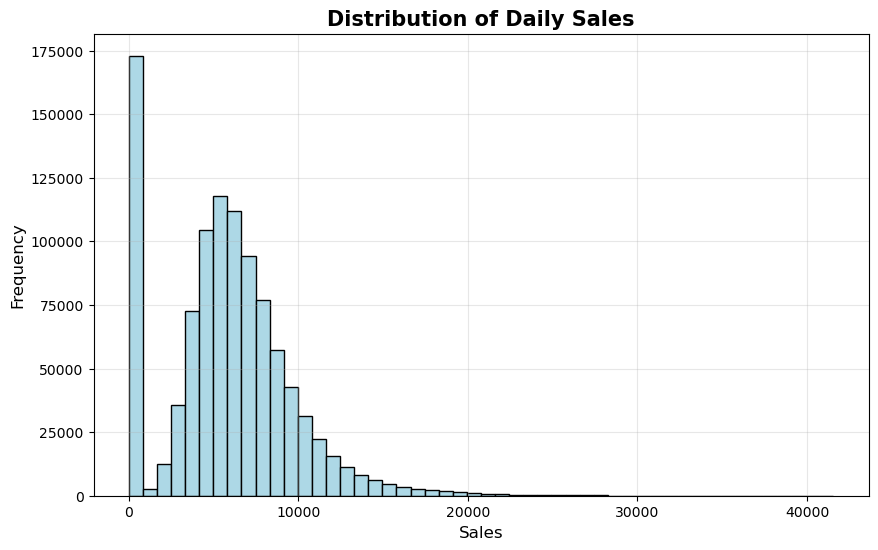

In [32]:
plt.figure(figsize=(10,6))

plt.hist(
    train_df["Sales"],
    bins=50,
    color="lightblue",
    edgecolor="black"
)

plt.title("Distribution of Daily Sales", fontsize=15, fontweight="bold")
plt.xlabel("Sales", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(alpha=0.3)

plt.show()

### Key Insights

- The sales distribution is **positively (right) skewed**, with most daily sales concentrated between **4,000 and 9,000**.
- A noticeable spike at **zero sales** indicates that a significant number of records correspond to days with no sales, likely due to store closures.
- A small number of observations have exceptionally high sales (above **20,000**), indicating the presence of outliers or peak sales events.
- The wide spread of sales values suggests considerable variation in store performance across different dates and locations.

### Business Recommendation

- Investigate zero-sales records using the `Open` feature and analyze high-sales days to identify the impact of promotions, holidays, or seasonal events.

# Distribution of Sales (Excluding Zero Sales)

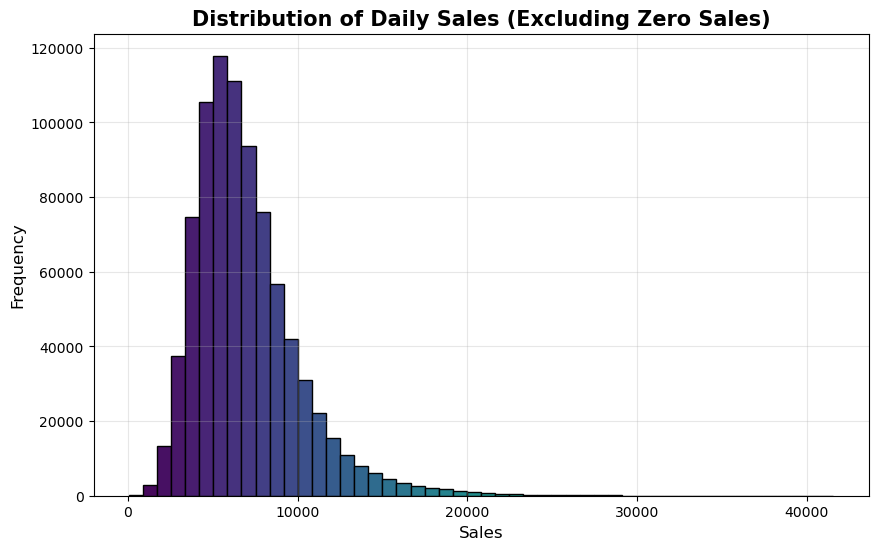

In [33]:
sales_non_zero = train_df[train_df["Sales"] > 0]

plt.figure(figsize=(10,6))
counts, bins, patches = plt.hist(
    sales_non_zero["Sales"],
    bins=50,
    edgecolor="black"
)
colors = plt.cm.viridis(np.linspace(0, 1, len(patches)))

for color, patch in zip(colors, patches):
    patch.set_facecolor(color)

plt.title("Distribution of Daily Sales (Excluding Zero Sales)",
          fontsize=15,
          fontweight="bold")
plt.xlabel("Sales", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(alpha=0.3)

plt.show()

### Key Insights

- After excluding zero-sales records, most daily sales are concentrated between **4,000 and 9,000**, indicating the typical sales range across stores.
- The distribution remains **positively (right) skewed**, with fewer observations at higher sales values.
- A small number of stores record exceptionally high sales (above **20,000**), suggesting peak demand during specific events such as promotions or holidays.
- The absence of zero-sales records provides a clearer representation of actual store sales performance.

### Business Recommendation

- Focus forecasting models on capturing the common sales range while ensuring they can handle occasional high-sales events driven by promotions, holidays, or seasonal demand.

# Box Plot

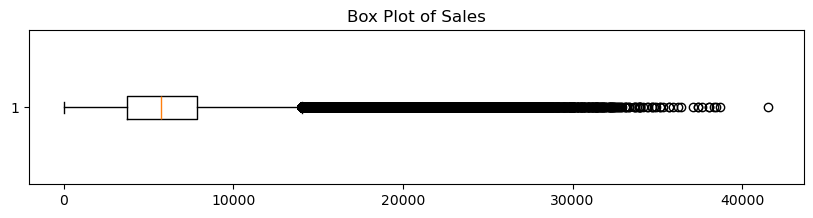

In [34]:
plt.figure(figsize=(10,2))

plt.boxplot(
    train_df["Sales"],
    vert=False
)

plt.title("Box Plot of Sales")

plt.show()

### Key Insights

- The median sales value lies around the center of the distribution, while the wide interquartile range (IQR) indicates considerable variation in daily sales across stores.
- A large number of observations appear beyond the upper whisker, confirming the presence of **high-value outliers**.
- The absence of significant lower-end outliers suggests that extreme values are primarily concentrated on the higher sales side.
- These high-sales observations are likely associated with promotions, holidays, or high-performing stores rather than data errors.

### Business Recommendation

- Investigate high-sales outliers before applying any outlier treatment, as they may represent valuable business events that should be retained for forecasting.

# Zero Sales Analysis

In [99]:
zero_sales = (train_df["Sales"] == 0).sum()

zero_sales_percentage = (
    zero_sales / len(train_df)
) * 100

print(f"Zero Sales Records : {zero_sales:,}")

print(f"Percentage         : {zero_sales_percentage:.2f}%")

Zero Sales Records : 172,871
Percentage         : 16.99%


### Key Insights

- Approximately **16.99%** of the records have zero sales, accounting for **172,871** observations in the dataset.
- A substantial proportion of zero-sales records suggests that many stores were likely **closed** rather than experiencing no customer demand.
- These records should be analyzed alongside the `Open` feature to distinguish store closures from actual zero-sales events.

### Business Recommendation

- Verify zero-sales records using the `Open` indicator and retain valid store closure records, as they represent real business operations and are important for accurate sales forecasting.

# Highest Sales Records

In [100]:
train_df.nlargest(
    10,
    "Sales"
)[["Store","Date","Sales","Customers"]]

,Store,Date,Sales,Customers
44393,909,2015-06-22,41551,1721
132946,262,2015-04-03,38722,5132
101726,262,2015-05-01,38484,5458
87231,262,2015-05-14,38367,5192
424086,57,2014-06-16,38037,1970
627776,817,2013-12-16,38025,4381
627220,261,2013-12-16,37646,1964
444361,262,2014-05-29,37403,5297
620531,262,2013-12-22,37376,4916
245945,262,2014-12-21,37122,4962


# Top Performing Stores in Top 10 Sales

In [101]:
top10_sales = train_df.nlargest(10, "Sales")

display(top10_sales["Store"].value_counts())

Store
262    6
909    1
57     1
817    1
261    1
Name: count, dtype: int64

### Key Insights

- **Store 262** dominates the top-performing stores, appearing **6 out of the top 10** highest sales records, indicating consistently exceptional sales performance.
- The highest recorded sale is **41,551** by **Store 909** on **22-Jun-2015**, while the remaining top sales mostly range between **37,000–39,000**.
- High sales are generally accompanied by **high customer footfall** (around **4,000–5,500** customers), suggesting a strong relationship between customer count and sales.
- The repeated appearance of the same stores in the top sales records indicates that store-specific factors, such as promotions, assortment, or store type, may significantly influence sales performance.

### Business Recommendation

- Conduct a detailed analysis of **Store 262** and **Store 909** to identify the operational and promotional factors driving their exceptional performance, and replicate these strategies across similar stores.

# Sales Quantiles

In [102]:
quantiles = train_df["Sales"].quantile(
    [0.25,0.50,0.75,0.90,0.95,0.99]
)

display(quantiles)

0.25    3727.00
0.50    5744.00
0.75    7856.00
0.90   10288.00
0.95   12137.00
0.99   17160.00
Name: Sales, dtype: float64

### Key Insights

- The **median daily sales** are **5,744**, indicating that half of the daily sales records fall below this value.
- **75%** of the sales records are below **7,856**, while only **10%** exceed **10,288**, highlighting that high sales occur relatively infrequently.
- The **99th percentile** reaches **17,160**, confirming the presence of a small number of exceptionally high sales days.
- The increasing gap between higher quantiles indicates a **right-skewed distribution** with a long tail of high-value sales.

### Business Recommendation

- Use high-performing sales days (95th and 99th percentiles) to identify the impact of promotions, holidays, and store-specific factors, and incorporate these insights into forecasting and business planning.

## Overall Summary

- Daily sales exhibit a **right-skewed distribution**, with most sales concentrated between **4,000 and 9,000**, while a small number of observations record exceptionally high sales.
- Approximately **16.99%** of the records have zero sales, indicating that store closures or non-operational days should be considered during forecasting.
- The box plot and quantile analysis confirm the presence of **high-value outliers**, which are likely driven by genuine business events such as promotions or holidays rather than data errors.
- **Store 262** consistently appears among the top-performing stores, suggesting that store-specific factors play a significant role in driving sales.
- Overall, the analysis indicates that sales are influenced by multiple factors, including customer footfall, store characteristics, promotions, and seasonal events, which should be incorporated into the predictive models.

# Customer Distribution Analysis

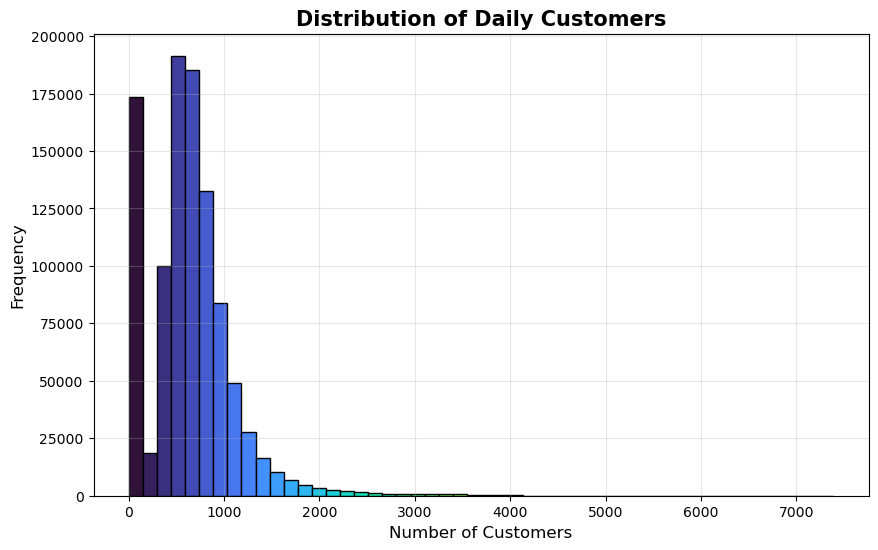

In [103]:
plt.figure(figsize=(10,6))

counts, bins, patches = plt.hist(
    train_df["Customers"],
    bins=50,
    edgecolor="black"
)
colors = plt.cm.turbo(np.linspace(0, 1, len(patches)))

for color, patch in zip(colors, patches):
    patch.set_facecolor(color)

plt.title("Distribution of Daily Customers", fontsize=15, fontweight="bold")
plt.xlabel("Number of Customers", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(alpha=0.3)

plt.show()

### Key Insights

- Most stores receive between **300 and 1,000 customers** per day, indicating the typical customer footfall across the dataset.
- The customer distribution is **positively (right) skewed**, with only a few stores recording exceptionally high customer counts.
- A noticeable number of records with **zero customers** likely correspond to days when stores were closed or not operational.
- The long right tail suggests that a small number of stores experience significantly higher customer traffic than the majority.

### Business Recommendation

- Analyze high-footfall stores separately to identify factors such as promotions, store type, or location that contribute to increased customer visits and replicate these strategies where appropriate.

# Customer Box Plot

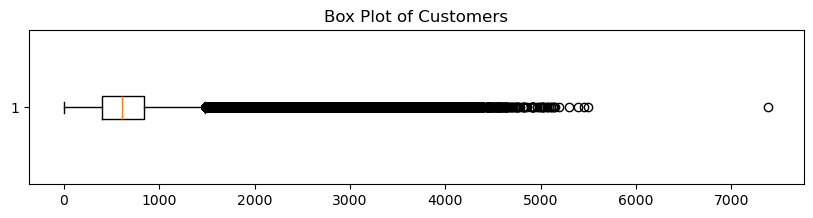

In [104]:
plt.figure(figsize=(10,2))

plt.boxplot(
    train_df["Customers"],
    vert=False
)

plt.title("Box Plot of Customers")

plt.show()

### Key Insights

- The customer distribution shows **considerable variability** across stores, with most observations concentrated within the interquartile range.
- A large number of **high-value outliers** indicate that some stores experience significantly higher customer footfall than the majority.
- The customer distribution is **right-skewed**, with extreme customer counts extending beyond the upper whisker.
- These outliers are likely associated with high-performing stores, promotional campaigns, or seasonal demand rather than data quality issues.

### Business Recommendation

- Analyze high-footfall stores to identify the operational and promotional factors driving increased customer visits and apply these best practices to similar stores.

# Sales vs Customers

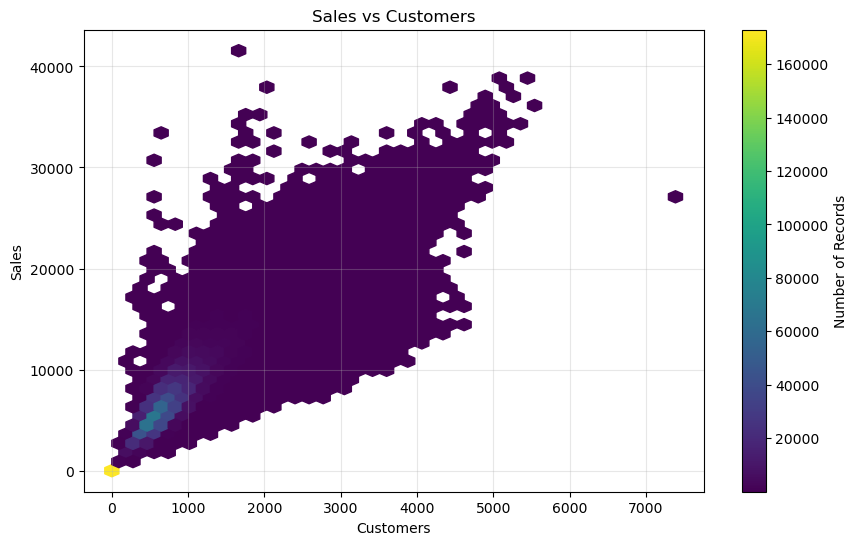

In [105]:
plt.figure(figsize=(10, 6))

plt.hexbin(
    train_df["Customers"],
    train_df["Sales"],
    gridsize=40,
    cmap="viridis",
    mincnt=1
)

plt.colorbar(label="Number of Records")

plt.title("Sales vs Customers")
plt.xlabel("Customers")
plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.show()

### Key Insights

- The hexbin plot indicates a **strong positive relationship** between customer count and sales, with sales generally increasing as customer footfall increases.
- The highest concentration of observations is between **500–1,000 customers** and **₹4,000–₹9,000** in daily sales, representing the typical operating range for most stores.
- While most records follow the upward trend, a few high-sales observations deviate from the main cluster, suggesting the influence of promotions, holidays, or store-specific factors.
- Stores with similar customer counts exhibit varying sales levels, indicating that customer footfall alone does not fully explain sales performance.

### Business Recommendation

- Combine customer data with other variables such as promotions, store type, holidays, and competition to improve sales forecasting and identify additional drivers of store performance.

In [106]:
# Select only numerical columns
numerical_columns = train_df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Correlation features
corr_features = numerical_columns

# Correlation matrix
corr_matrix = train_df[corr_features].corr()

# Correlation

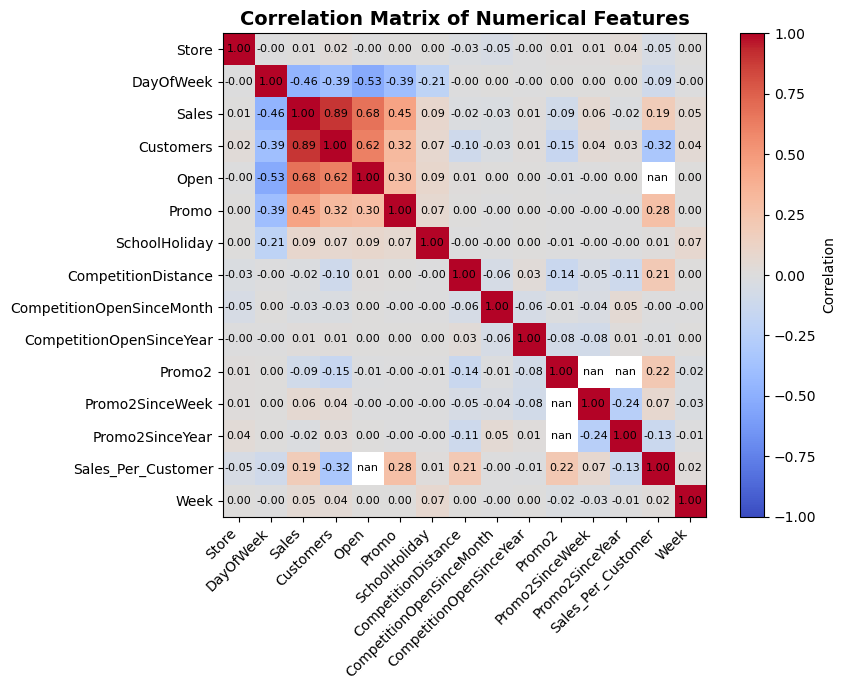

In [107]:
corr_features = numerical_columns

corr_matrix = train_df[corr_features].corr()

plt.figure(figsize=(9,7))


plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_features)), corr_features, rotation=45, ha="right")
plt.yticks(range(len(corr_features)), corr_features)

for i in range(len(corr_features)):
    for j in range(len(corr_features)):
        plt.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="black"
        )

plt.title("Correlation Matrix of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Key Insights

- **Customers** exhibit the strongest positive correlation with **Sales (0.89)**, indicating that higher customer footfall is strongly associated with increased sales.

- **Store Open status** shows a strong positive correlation with **Sales (0.68)**, suggesting that stores generate significantly higher sales when they are open.

- **Promotional campaigns (Promo)** have a moderate positive correlation with **Sales (0.45)**, indicating that promotions generally contribute to increased sales performance.

- **Competition Distance (-0.02)**, **School Holiday (0.09)**, **Competition Open Since Month (-0.03)**, and **Competition Open Since Year (0.01)** display very weak correlations with **Sales**, suggesting they have limited direct linear influence on sales.

- **Sales Per Customer** has a weak positive correlation with **Sales (0.19)**, indicating that overall sales are driven more by customer volume than by spending per customer.

- Most predictor variables exhibit **weak to moderate correlations** with one another, indicating **no evidence of severe multicollinearity**, although variables such as **Customers** and **Open** show moderate positive relationships.

# Top Customer Records

In [108]:
top_customers = train_df.nlargest(
    10,
    "Customers"
)

display(
    top_customers[
        ["Store", "Date", "Customers", "Sales"]
    ]
)


,Store,Date,Customers,Sales
993496,817,2013-01-22,7388,27190
319810,262,2014-10-03,5494,35702
101726,262,2015-05-01,5458,38484
432096,262,2014-06-09,5387,34692
444361,262,2014-05-29,5297,37403
87231,262,2015-05-14,5192,38367
129601,262,2015-04-06,5152,33655
745411,262,2013-09-01,5145,32926
132946,262,2015-04-03,5132,38722
776631,262,2013-08-04,5112,32252


### Key Insights

- **Store 262** appears in **9 out of the top 10** customer records, indicating consistently high customer footfall.
- **Store 817** recorded the highest customer count (**7,388**), but its sales (**27,190**) were lower than several records from Store 262.
- Stores with similar customer counts generated different sales values, suggesting that **customer volume alone does not determine sales performance**.
- The repeated presence of **Store 262** highlights the influence of store-specific factors such as promotions, assortment, or operational efficiency.

### Business Recommendation

- Analyze the business strategies of **Store 262** to understand how it consistently converts high customer traffic into strong sales and replicate these practices across similar stores.

# Customer Quantiles

In [109]:
customer_quantiles = train_df["Customers"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

display(customer_quantiles)

0.25    405.00
0.50    609.00
0.75    837.00
0.90   1116.00
0.95   1362.00
0.99   2267.00
Name: Customers, dtype: float64

### Key Insights

- The **median daily customer count** is **609**, indicating that half of the stores receive fewer than 609 customers per day.
- **75%** of the records have fewer than **837** customers, while only **10%** exceed **1,116** customers, showing that high customer footfall is relatively uncommon.
- The **99th percentile** reaches **2,267** customers, confirming that only a small proportion of stores experience exceptionally high customer traffic.
- The increasing gap between higher quantiles indicates a **right-skewed distribution**, with a few stores attracting significantly more customers than the majority.

### Business Recommendation

- Identify the factors contributing to high customer footfall in top-performing stores and use these insights to improve customer acquisition strategies across other stores.

# Average Sales Per Customer


In [110]:
train_df["Sales_Per_Customer"] = (
    train_df["Sales"] /
    train_df["Customers"]
)

train_df["Sales_Per_Customer"] = train_df[
    "Sales_Per_Customer"
].replace([np.inf, -np.inf], np.nan)

display(
    train_df["Sales_Per_Customer"].describe()
)

count   844340.00
mean         9.49
std          2.20
min          0.00
25%          7.90
50%          9.25
75%         10.90
max         64.96
Name: Sales_Per_Customer, dtype: float64

### Key Insights

- The average sales per customer is **9.49**, while the median is **9.25**, indicating relatively consistent customer spending across most stores.
- **75%** of customer transactions generate sales of **10.90 or less**, suggesting a fairly stable spending pattern.
- The maximum value of **64.96** indicates that a few transactions or stores achieve significantly higher revenue per customer.
- The small difference between the mean and median suggests that customer spending is generally stable, with only a few high-spending outliers.

### Business Recommendation

- Identify stores with higher **Sales Per Customer** to understand successful pricing, product assortment, or promotional strategies, and replicate these practices across other stores to increase revenue without relying solely on higher customer footfall.

# Overall Summary

- Customer footfall is **right-skewed**, with most stores receiving **400–1,000 customers** per day.
- **Customers** have a **strong positive correlation (0.89)** with **Sales**, making them a key driver of revenue.
- Similar customer counts can generate different sales, highlighting the impact of **promotions, store characteristics, and customer spending**.
- The average **Sales Per Customer** is **9.49**, indicating relatively consistent customer spending, with a few stores achieving significantly higher revenue per customer.

# Promotion Analysis

# Average Sales by Promotion

,Promo,Sales
0,0,4406.05
1,1,7991.15


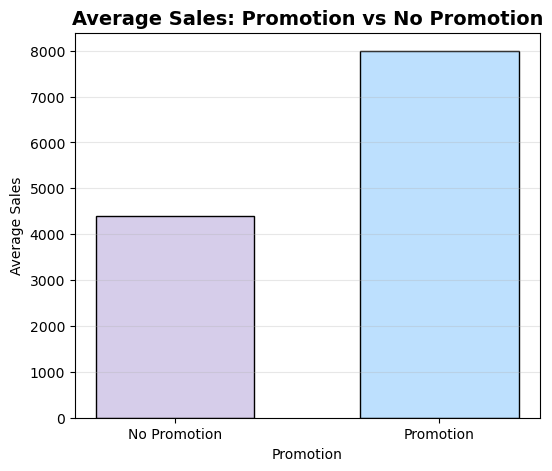

In [111]:
promo_sales = (
    train_df
    .groupby("Promo")["Sales"]
    .mean()
    .reset_index()
)
display(promo_sales)

plt.figure(figsize=(6,5))

plt.bar(
    promo_sales["Promo"],
    promo_sales["Sales"],
    color=["#D6CDEA", "#BDE0FE"],
    edgecolor="black",
    width=0.6
)

plt.xticks([0, 1], ["No Promotion", "Promotion"])

plt.title("Average Sales: Promotion vs No Promotion",
          fontsize=14,
          fontweight="bold")
plt.xlabel("Promotion")
plt.ylabel("Average Sales")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Key Insights

- Stores running promotions generate an average sales of **7,991**, compared to **4,406** without promotions.
- Promotional campaigns increase average sales by approximately **81%**, highlighting their strong impact on revenue.
- The clear difference between the two groups indicates that promotions are an effective strategy for boosting daily sales.

### Business Recommendation

- Continue using promotional campaigns during key business periods while evaluating their profitability and return on investment (ROI).

In [112]:
# Average customers with and without promotion
promo_customers = train_df.groupby("Promo")[["Customers"]].mean().reset_index()

display(promo_customers)

# Percentage increase in customers due to promotion
customer_increase = (
    (promo_customers.loc[promo_customers["Promo"] == 1, "Customers"].values[0] -
     promo_customers.loc[promo_customers["Promo"] == 0, "Customers"].values[0])
    /
    promo_customers.loc[promo_customers["Promo"] == 0, "Customers"].values[0]
) * 100

print(f"Customer Footfall Increase due to Promotion: {customer_increase:.2f}%")

,Promo,Customers
0,0,517.82
1,1,820.10


Customer Footfall Increase due to Promotion: 58.37%


# Average Customers by Promotion

Customer Footfall Increase due to Promotion: 58.37%


,Promo,Customers
0,0,517.82
1,1,820.10


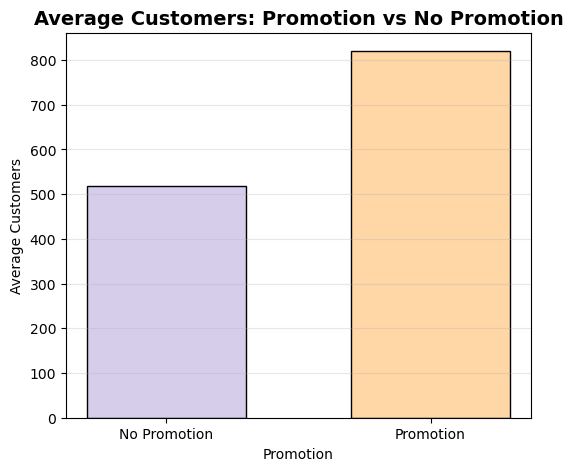

In [113]:
print(f"Customer Footfall Increase due to Promotion: {customer_increase:.2f}%")
display(promo_customers)

plt.figure(figsize=(6,5))

plt.bar(
    ["No Promotion", "Promotion"],      
    promo_customers["Customers"],
    color=["#D6CDEA", "#FFD6A5"],
    edgecolor="black",
    width=0.6
)

plt.title("Average Customers: Promotion vs No Promotion", fontsize=14, fontweight="bold")
plt.xlabel("Promotion")
plt.ylabel("Average Customers")
plt.grid(axis="y", alpha=0.3)

plt.show()


### Key Insights

- Stores with promotions attract an average of **820 customers**, compared to **518 customers** without promotions.
- Promotional campaigns increase customer footfall by approximately **58%**, demonstrating their effectiveness in attracting more visitors.
- The increase in customer traffic aligns with the higher sales observed during promotional periods, indicating that promotions positively influence both store visits and revenue.

### Business Recommendation

- Leverage promotional campaigns during peak shopping periods to maximize customer footfall and sales while regularly evaluating campaign performance.

# Sales Distribution by Promotion

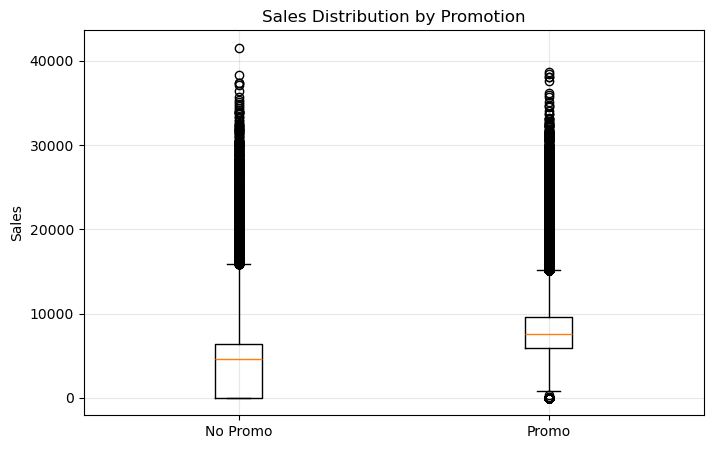

In [114]:
promo_groups = [
    train_df.loc[train_df["Promo"] == 0, "Sales"],
    train_df.loc[train_df["Promo"] == 1, "Sales"]
]

plt.figure(figsize=(8,5))

plt.boxplot(
    promo_groups,
    tick_labels=["No Promo", "Promo"]
)

plt.title("Sales Distribution by Promotion")
plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.show()

### Key Insights

- The **median sales** are noticeably higher during promotional periods, indicating that promotions consistently increase daily sales.
- The **interquartile range (IQR)** is higher for promotional days, suggesting greater variability in sales during promotions.
- Both promotional and non-promotional days contain several high-value outliers, representing exceptional sales events.
- Despite the presence of outliers, the overall sales distribution shifts upward during promotions, confirming their positive impact on revenue.

### Business Recommendation

- Continue implementing promotions, as they not only increase average sales but also improve the overall sales distribution across stores.

In [115]:
# Average Sales Per Customer by Promotion
promo_spc = train_df.groupby("Promo")[["Sales_Per_Customer"]].mean().reset_index()

display(promo_spc)

# Calculate percentage increase
sales_per_customer_increase = (
    (
        promo_spc.loc[promo_spc["Promo"] == 1, "Sales_Per_Customer"].values[0]
        - promo_spc.loc[promo_spc["Promo"] == 0, "Sales_Per_Customer"].values[0]
    )
    / promo_spc.loc[promo_spc["Promo"] == 0, "Sales_Per_Customer"].values[0]
) * 100

print(f"Sales Per Customer Increase due to Promotion: {sales_per_customer_increase:.2f}%")

,Promo,Sales_Per_Customer
0,0,8.94
1,1,10.18


Sales Per Customer Increase due to Promotion: 13.84%


# Sales Per Customer by Promotion

Sales Per Customer Increase due to Promotion: 13.84%


,Promo,Sales_Per_Customer
0,0,8.94
1,1,10.18


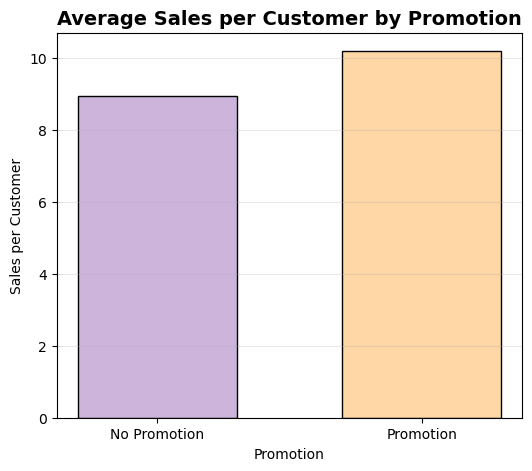

In [116]:
import logging
logging.getLogger("matplotlib.category").setLevel(logging.ERROR)

print(f"Sales Per Customer Increase due to Promotion: {sales_per_customer_increase:.2f}%")

display(promo_spc) 

plt.figure(figsize=(6,5))

plt.bar(
    ["No Promotion", "Promotion"],           
    promo_spc["Sales_Per_Customer"],         
    color=["#CDB4DB", "#FFD6A5"],            
    edgecolor="black",
    width=0.6
)

plt.title("Average Sales per Customer by Promotion",
          fontsize=14,
          fontweight="bold")
plt.xlabel("Promotion")
plt.ylabel("Sales per Customer")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Key Insights

- Customers spend an average of **10.18** during promotional periods, compared to **8.94** without promotions.
- Promotions increase **Sales Per Customer** by approximately **14%**, indicating that customers purchase more during promotional campaigns.
- The combination of higher customer footfall and increased spending per customer significantly contributes to overall sales growth.

### Business Recommendation

- Continue offering targeted promotions that encourage customers to purchase more items, maximizing both customer traffic and average transaction value.

# Average Sales by Promo2

Sales Per Customer Increase due to Promo2: 10.52%


,Promo2,Sales_Per_Customer
0,0,9.02
1,1,9.97


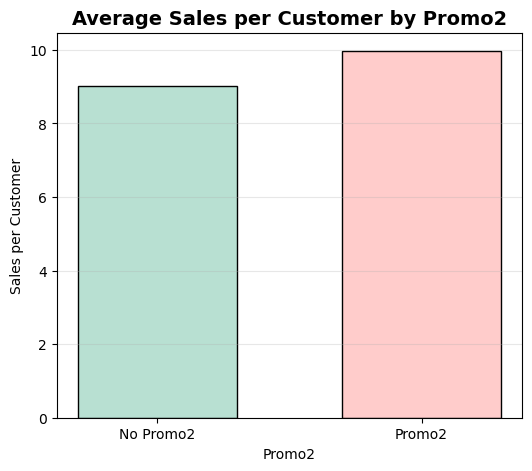

In [117]:
promo2_spc = (
    train_df
    .groupby("Promo2")["Sales_Per_Customer"]
    .mean()
    .reset_index()
)
no_promo2 = promo2_spc.loc[
    promo2_spc["Promo2"] == 0, "Sales_Per_Customer"
].values[0]

with_promo2 = promo2_spc.loc[
    promo2_spc["Promo2"] == 1, "Sales_Per_Customer"
].values[0]

promo2_increase = ((with_promo2 - no_promo2) / no_promo2) * 100

print(f"Sales Per Customer Increase due to Promo2: {promo2_increase:.2f}%")

display(promo2_spc)

plt.figure(figsize=(6,5))

plt.bar(
    ["No Promo2", "Promo2"],
    promo2_spc["Sales_Per_Customer"],
    color=["#B8E0D2", "#FFCCCB"],   # Light Mint & Light Pink
    edgecolor="black",
    width=0.6
)

plt.title("Average Sales per Customer by Promo2", fontsize=14, fontweight="bold")
plt.xlabel("Promo2")
plt.ylabel("Sales per Customer")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Key Insights

- Stores with **Promo2** generate **11.45% lower average sales** compared to stores without Promo2.
- However, **Sales Per Customer increases by 10.52%**, indicating that customers visiting Promo2 stores spend more on average.
- This suggests that Promo2 improves **customer spending efficiency**, but does not necessarily increase overall store revenue.
- The lower total sales may be influenced by reduced customer footfall, store characteristics, or market conditions rather than the promotion itself.

### Business Recommendation

- Analyze Promo2 performance across different store types and regions to identify where it delivers the highest value, and consider combining it with short-term promotions to increase both customer traffic and revenue.

# Time Series & Seasonal Analysis

In [118]:
# Convert Date to datetime

train_df["Date"] = pd.to_datetime(train_df["Date"])

# Create time-based features

train_df["Year"] = train_df["Date"].dt.year
train_df["Month"] = train_df["Date"].dt.month
train_df["Day"] = train_df["Date"].dt.day

In [119]:
train_df[["Date", "Year", "Month", "Day"]].head()
monthly_sales = (
    train_df.groupby("Month")["Sales"]
    .mean()
    .reset_index()
)

display(monthly_sales)

,Month,Sales
0,1,5465.40
1,2,5645.25
2,3,5784.58
3,4,5738.87
4,5,5489.64
5,6,5760.96
6,7,6064.92
7,8,5693.02
8,9,5570.25
9,10,5537.04


# Feature Extraction from Date

In [120]:
train_df["Date"] = pd.to_datetime(train_df["Date"])

train_df["Year"] = train_df["Date"].dt.year
train_df["Month"] = train_df["Date"].dt.month
train_df["Day"] = train_df["Date"].dt.day
train_df["Week"] = train_df["Date"].dt.isocalendar().week.astype(int)
train_df["Quarter"] = train_df["Date"].dt.quarter

display(
    train_df[
        ["Date", "Year", "Month", "Week", "Quarter"]
    ].head()
)

,Date,Year,Month,Week,Quarter
0,2015-07-31,2015,7,31,3
1,2015-07-31,2015,7,31,3
2,2015-07-31,2015,7,31,3
3,2015-07-31,2015,7,31,3
4,2015-07-31,2015,7,31,3


# Monthly Sales Trend

,Month,Sales
0,1,5465.40
1,2,5645.25
2,3,5784.58
3,4,5738.87
4,5,5489.64
5,6,5760.96
6,7,6064.92
7,8,5693.02
8,9,5570.25
9,10,5537.04


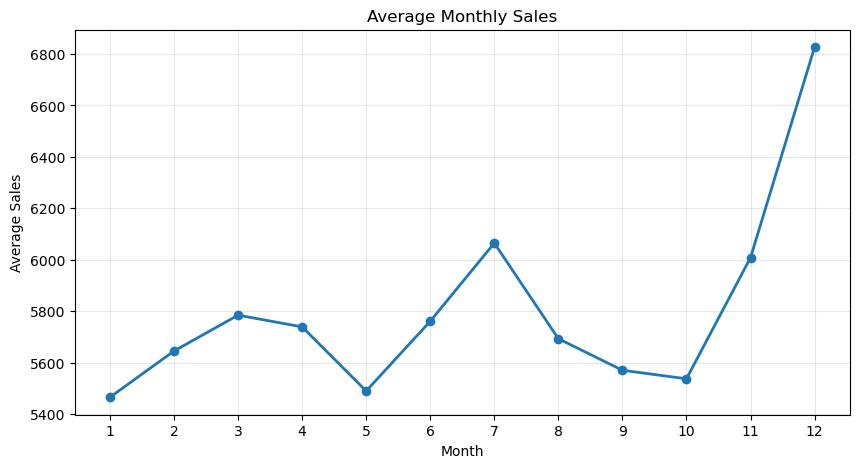

In [121]:
monthly_sales = (
    train_df.groupby("Month")["Sales"]
    .mean()
    .reset_index()
)

display(monthly_sales)

plt.figure(figsize=(10,5))
plt.plot(
    monthly_sales["Month"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(range(1,13))
plt.grid(alpha=0.3)

plt.show()

### Key Insights

- Sales exhibit a clear **seasonal trend**, with noticeable fluctuations throughout the year.
- **December** records the **highest average sales**, indicating a strong year-end holiday shopping effect.
- A secondary sales peak is observed in **July**, suggesting increased customer demand during the mid-year period.
- **January** and **May** show the lowest average sales, representing relatively weaker business periods.
- Sales begin to rise significantly from **November to December**, highlighting the importance of festive and holiday seasons.

### Business Recommendation

- Increase inventory, staffing, and promotional activities during **November and December** to capitalize on peak demand.
- Introduce targeted marketing campaigns during low-performing months such as **January** and **May** to improve sales performance.

# Average Sales by Day of Week

,DayOfWeek,Sales
0,1,7809.04
1,2,7005.24
2,3,6555.88
3,4,6247.58
4,5,6723.27
5,6,5847.56
6,7,204.18


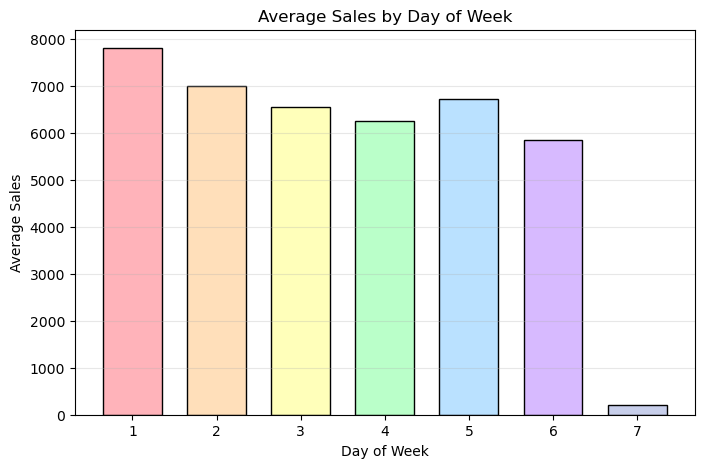

In [122]:
weekday_sales = (
    train_df.groupby("DayOfWeek")["Sales"]
    .mean()
    .reset_index()
)

display(weekday_sales)

plt.figure(figsize=(8,5))

plt.bar(
    weekday_sales["DayOfWeek"],
    weekday_sales["Sales"],
    color=["#FFB3BA", "#FFDFBA", "#FFFFBA", "#BAFFC9", "#BAE1FF", "#D7BAFF", "#C7CEEA"],
    edgecolor="black",
    width=0.7
)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Key Insights

- **Day 1** records the highest average sales, making it the strongest-performing day of the week.
- Sales gradually decline from **Day 2 to Day 6**, indicating reduced customer activity as the week progresses.
- **Day 7** has extremely low average sales, suggesting that most stores are closed or have limited operations on that day.
- The variation in sales across weekdays highlights clear differences in customer shopping behavior throughout the week.

### Business Recommendation

- Allocate more inventory and staff on **Day 1** to meet peak demand.
- Introduce targeted promotions during **Days 4–6** to boost customer traffic and improve sales.

# School Holiday Analysis

,SchoolHoliday,Sales
0,0,5620.98
1,1,6476.52


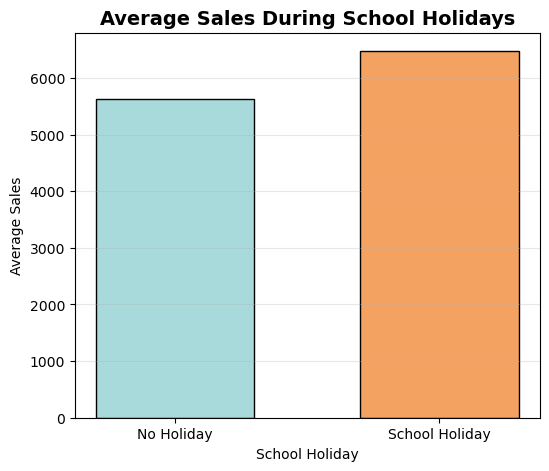

In [123]:
holiday_sales = (
    train_df.groupby("SchoolHoliday")["Sales"]
    .mean()
    .reset_index()
)

display(holiday_sales)

plt.figure(figsize=(6,5))

plt.bar(
    holiday_sales["SchoolHoliday"],        # Numeric values (no INFO message)
    holiday_sales["Sales"],
    color=["#A8DADC", "#F4A261"],          # Light colors
    edgecolor="black",
    width=0.6
)

plt.xticks([0, 1], ["No Holiday", "School Holiday"])

plt.title("Average Sales During School Holidays", fontsize=14, fontweight="bold")
plt.xlabel("School Holiday")
plt.ylabel("Average Sales")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Key Insights

- Stores generate **higher average sales during school holidays** compared to non-holiday periods.
- The increase in sales suggests that school holidays positively influence customer shopping activity.
- Families and students likely contribute to the higher demand during holiday periods.

### Business Recommendation

- Plan promotional campaigns, increase inventory, and optimize staffing during school holidays to maximize sales opportunities.

# Store-Level Performance Analysis
### Top 10 Stores by Average Sales

,Store,Sales
0,262,20718.52
1,817,18108.14
2,562,17969.56
3,1114,17200.20
4,251,15814.09
5,842,15242.11
6,513,15129.94
7,788,14949.19
8,733,14933.29
9,383,14320.47


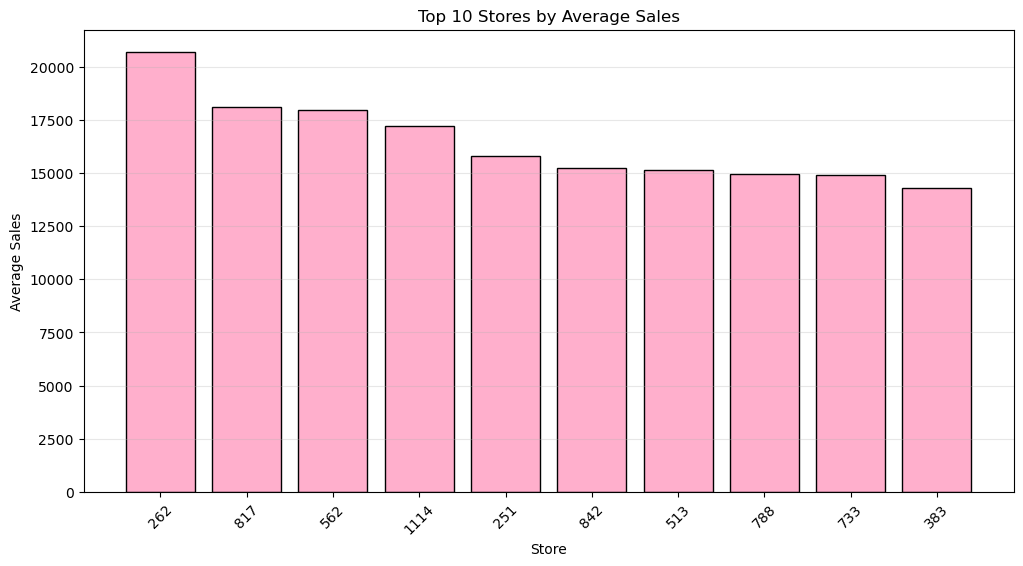

In [124]:
top_stores = (
    train_df.groupby("Store")["Sales"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

display(top_stores)

plt.figure(figsize=(12,6))

plt.bar(
    top_stores["Store"].astype(str),
    top_stores["Sales"],
    color="#FFAFCC",     
    edgecolor="black"
)

plt.title("Top 10 Stores by Average Sales")
plt.xlabel("Store")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.show()

### Insights: Top 10 Stores by Average Sales

- Store **262** recorded the highest average sales (over **20,000**), making it the best-performing store in the dataset.
- Stores **817, 562, and 1114** also demonstrated consistently high average sales, exceeding **17,000**.
- The top-performing stores significantly outperform the overall dataset average, indicating strong customer demand and operational efficiency.
- These stores can serve as benchmarks for identifying successful business strategies that can be replicated across other locations.

# Bottom 10 Stores by Average Sales

,Store,Sales
0,307,2244.50
1,543,2313.47
2,198,2407.93
3,208,2443.79
4,841,2461.40
5,254,2485.84
6,972,2550.56
7,794,2553.48
8,219,2591.47
9,210,2641.31


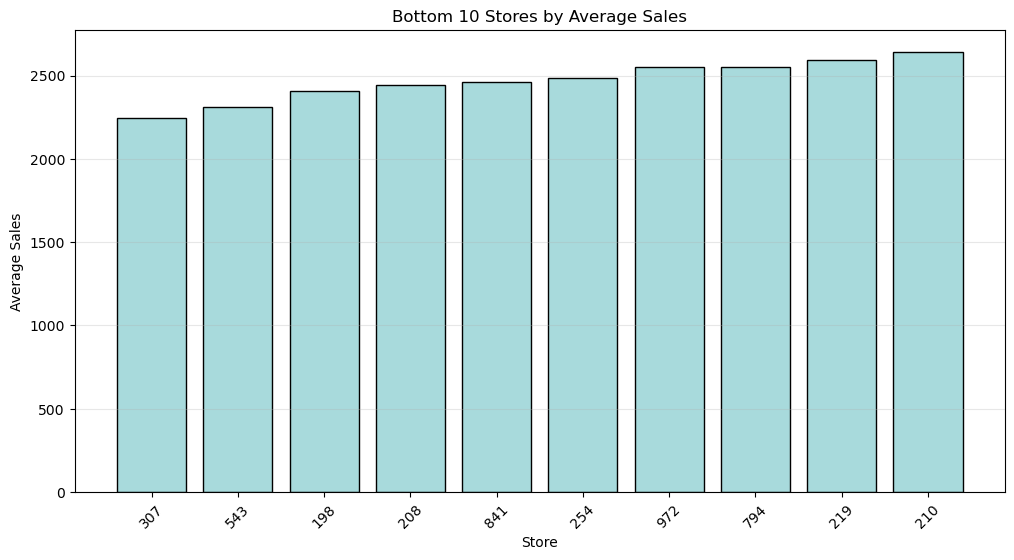

In [125]:
bottom_stores = (
    train_df.groupby("Store")["Sales"]
    .mean()
    .sort_values()
    .head(10)
    .reset_index()
)

display(bottom_stores)

plt.figure(figsize=(12,6))

plt.bar(
    bottom_stores["Store"].astype(str),
    bottom_stores["Sales"],
    color="#A8DADC",
    edgecolor="black"
)

plt.title("Bottom 10 Stores by Average Sales")
plt.xlabel("Store")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.show()

### Insights: Bottom 10 Stores by Average Sales

- Store **307** recorded the lowest average sales (approximately **2,250**), followed closely by stores **543** and **198**.
- All bottom-performing stores generated average sales between **2,200–2,700**, which is substantially lower than the top-performing stores.
- The large performance gap highlights potential issues such as weaker customer traffic, ineffective promotions, or operational challenges.
- These stores should be prioritized for performance improvement initiatives and further business analysis.

# Store Type Analysis

,StoreType,Sales
0,a,5738.18
1,b,10058.84
2,c,5723.63
3,d,5641.82


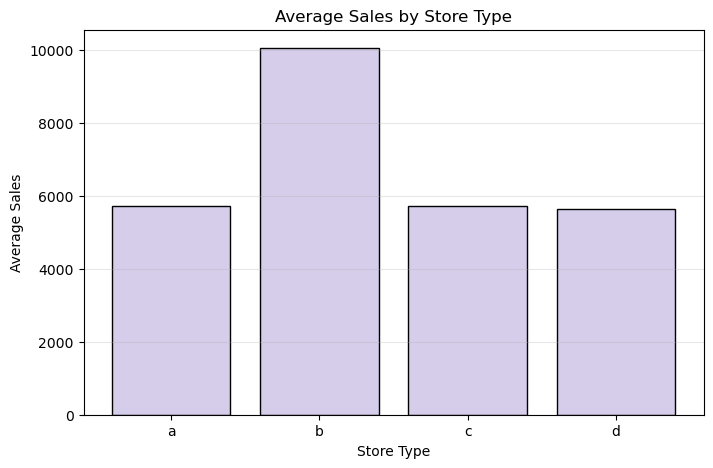

In [126]:
import logging
logging.getLogger("matplotlib.category").setLevel(logging.ERROR)

store_type_sales = (
    train_df.groupby("StoreType")["Sales"]
    .mean()
    .reset_index()
)

display(store_type_sales)

plt.figure(figsize=(8,5))

plt.bar(
    store_type_sales["StoreType"],
    store_type_sales["Sales"],
    color="#D6CDEA",      # Light Sky Blue
    edgecolor="black"
)

plt.title("Average Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Sales")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Insights: Average Sales by Store Type

- **Store Type 'b'** achieved the highest average sales (approximately **10,000**), outperforming all other store types.
- Store Types **'a'**, **'c'**, and **'d'** generated relatively similar average sales, ranging between **5,600–5,800**.
- The strong performance of Store Type 'b' suggests that its format, layout, or customer offerings are more effective in driving revenue.
- Expanding or adopting successful practices from Store Type 'b' could improve sales across other store formats.

# Assortment Analysis

,Assortment,Sales
0,a,5481.03
1,b,8553.93
2,c,6058.68


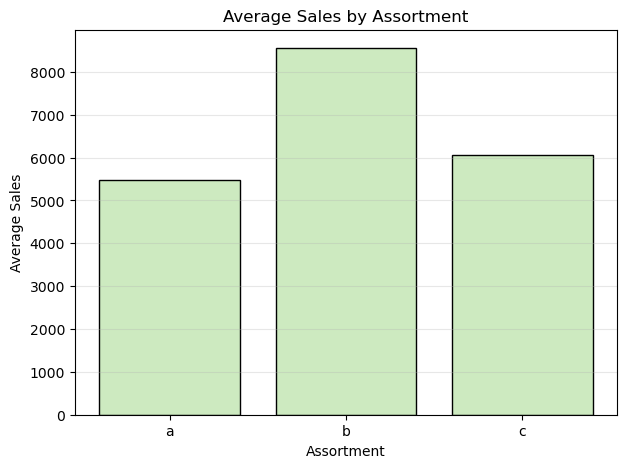

In [127]:
assortment_sales = (
    train_df.groupby("Assortment")["Sales"]
    .mean()
    .reset_index()
)

display(assortment_sales)

plt.figure(figsize=(7,5))

plt.bar(
    assortment_sales["Assortment"],
    assortment_sales["Sales"],
    color="#CDEAC0",      # Light Green
    edgecolor="black"
)

plt.title("Average Sales by Assortment")
plt.xlabel("Assortment")
plt.ylabel("Average Sales")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Insights: Average Sales by Assortment

- **Assortment 'b'** recorded the highest average sales (approximately **8,554**), making it the best-performing assortment category.
- **Assortment 'c'** ranked second with average sales of approximately **6,059**, while **Assortment 'a'** generated the lowest sales.
- Stores offering Assortment 'b' appear to attract higher customer spending compared to other assortment types.
- Product assortment plays an important role in influencing store sales performance.

# Competition Distance Analysis

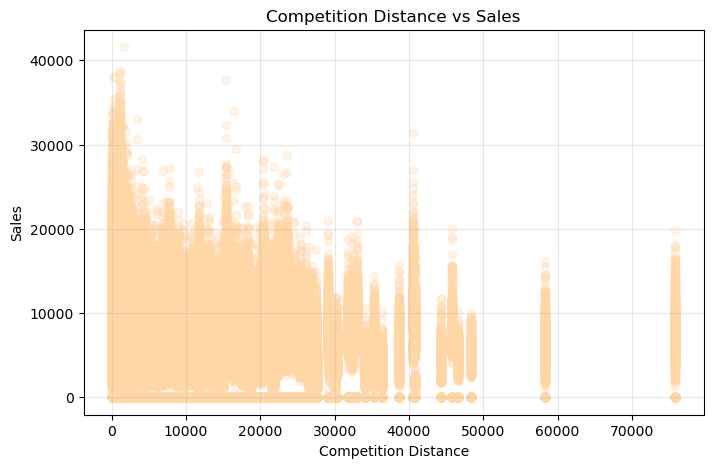

Correlation: -0.019


In [128]:
plt.figure(figsize=(8,5))

plt.scatter(
    train_df["CompetitionDistance"],
    train_df["Sales"],
    color="#FFD6A5",      
    alpha=0.25
)

plt.title("Competition Distance vs Sales")
plt.xlabel("Competition Distance")
plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.show()

print(
    f"Correlation: {train_df['CompetitionDistance'].corr(train_df['Sales']):.3f}"
)

### Insights: Competition Distance vs Sales

- The correlation between **Competition Distance and Sales is -0.019**, indicating an almost negligible negative relationship.
- The scatter plot shows no clear linear trend, as stores with both high and low sales are distributed across all competition distances.
- Several stores located close to competitors still achieved high sales, suggesting that proximity to competitors does not necessarily reduce business performance.
- Sales appear to be influenced more by factors such as customer traffic, promotions, store type, and product assortment than by competition distance alone.
- Overall, competition distance is not a strong predictor of store sales in this dataset.

## Final Summary

- Customer traffic is the strongest driver of sales, with a high positive correlation (0.89) between customers and sales.
- Promotions, school holidays, and seasonal demand (especially in December) significantly increase sales and customer visits.
- Store Type **'b'** and Assortment **'b'** consistently achieve the highest average sales.
- Store performance varies considerably, while competition distance has little influence on sales.

## Business Recommendations

- Increase promotional activities during low-sales periods and replicate successful strategies from top-performing stores.
- Expand Store Type **'b'** and optimize product assortment based on the success of Assortment **'b'**.
- Improve underperforming stores through targeted marketing, inventory optimization, and enhanced customer experience rather than focusing on competitor proximity.

# Multivariate Analysis
# Sales by Store Type and Promotion

,StoreType,Promo,Sales
0,a,0,4300.42
1,a,1,8068.08
2,b,0,9409.43
3,b,1,11109.74
4,c,0,4435.04
5,c,1,7810.17
6,d,0,4326.66
7,d,1,7776.59


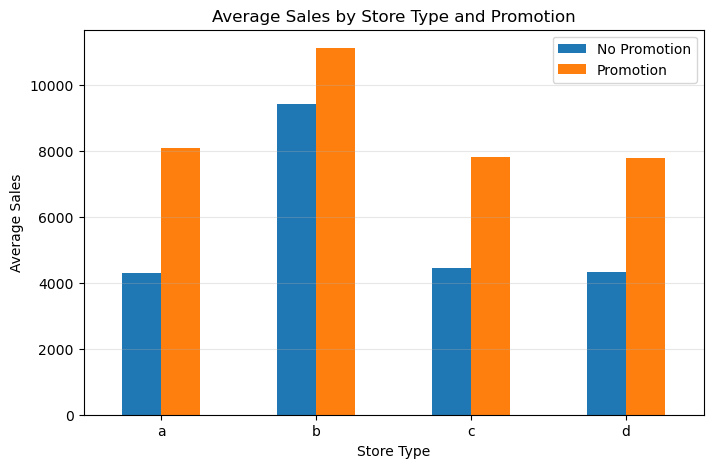

In [129]:
sales_store_promo = (
    train_df.groupby(["StoreType", "Promo"])["Sales"]
    .mean()
    .reset_index()
)

display(sales_store_promo)

import matplotlib.pyplot as plt

pivot_data = sales_store_promo.pivot(
    index="StoreType",
    columns="Promo",
    values="Sales"
)

pivot_data.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Sales by Store Type and Promotion")
plt.xlabel("Store Type")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.legend(["No Promotion","Promotion"])
plt.grid(axis="y", alpha=0.3)

plt.show()

### Insight

- Store Type **B** achieved the highest average sales in both promotional and non-promotional periods, indicating that it consistently outperforms the other store types.
- Promotions increased average sales across **all store types**, confirming that promotional campaigns have a positive impact on revenue.
- The largest sales uplift from promotions was observed in **Store Types A, C, and D**, where average sales nearly doubled compared to periods without promotions.
- Although **Store Type B** also benefited from promotions, its percentage increase was relatively smaller because it already had a high baseline sales performance.
- Overall, promotional activities are particularly effective for lower-performing store types, helping reduce the sales gap between stores.

# Promotion Impact (%) for each Store Type

In [130]:


promo_impact = (
    sales_store_promo
    .pivot(index="StoreType", columns="Promo", values="Sales")
)

promo_impact.columns = ["No Promo", "Promo"]

promo_impact["Promotion Increase (%)"] = (
    (promo_impact["Promo"] - promo_impact["No Promo"])
    / promo_impact["No Promo"]
) * 100

display(promo_impact.round(2))

,No Promo,Promo,Promotion Increase (%)
StoreType,,,
a,4300.42,8068.08,87.61
b,9409.43,11109.74,18.07
c,4435.04,7810.17,76.10
d,4326.66,7776.59,79.74


### Insights & Business Recommendations: Store Type vs Promotion

- Promotions increased average sales across all store types, with **Store Type 'a'** showing the highest improvement (**87.61%**), followed by **Store Types 'd' (79.74%)** and **'c' (76.10%)**.
- **Store Type 'b'** maintained the highest average sales overall, but promotions had a relatively smaller impact (**18.07%**) compared to other store types.
- **Recommendation:** Prioritize promotional campaigns for **Store Types 'a'**, **'c'**, and **'d'** to maximize sales growth, while focusing on customer retention and operational efficiency for **Store Type 'b'**.

# Store Type vs Assortment

,StoreType,Assortment,Sales
0,a,a,5398.86
1,a,c,6310.87
2,b,a,10821.62
3,b,b,8553.93
4,b,c,17969.56
5,c,a,5647.17
6,c,c,5805.78
7,d,a,5317.89
8,d,c,5826.41


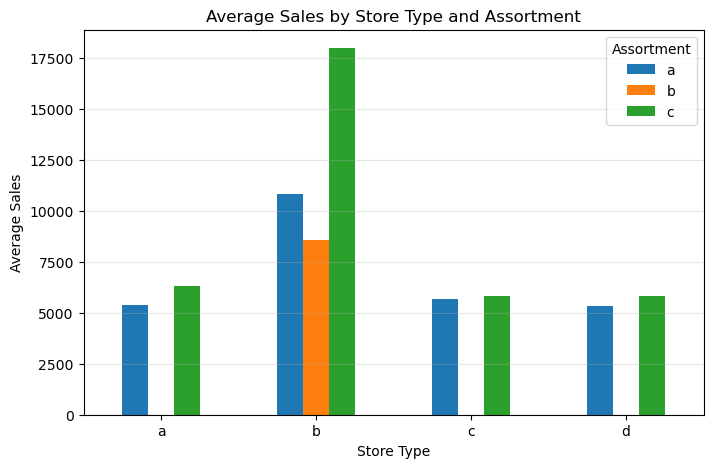

In [131]:
sales_store_assortment = (
    train_df.groupby(["StoreType", "Assortment"])["Sales"]
    .mean()
    .reset_index()
)

display(sales_store_assortment)

pivot_assortment = sales_store_assortment.pivot(
    index="StoreType",
    columns="Assortment",
    values="Sales"
)

pivot_assortment.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Sales by Store Type and Assortment")
plt.xlabel("Store Type")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Insights & Business Recommendations: Store Type vs Assortment

- **Store Type 'b' with Assortment 'c'** achieved the highest average sales (~18,000), making it the best-performing store-assortment combination.
- Across almost all store types, **Assortment 'c'** consistently generated higher sales than Assortment 'a', indicating that a broader product assortment attracts more customers and increases revenue.
- **Assortment 'b'** appears only for **Store Type 'b'** and performs lower than Assortment 'c', suggesting that expanding the assortment further can improve sales.
- **Recommendation:** Increase the availability of **Assortment 'c'**, particularly in **Store Types 'a'**, **'c'**, and **'d'**, while using **Store Type 'b'** as a benchmark for assortment planning and inventory optimization.

# Feature Engineering & Data Preprocessing
### Creating Model Dataset

In [132]:
model_df = train_df.copy()

# Drop columns not useful for prediction
drop_cols = [
    "Date",
    "Sales"
]

model_df = model_df.drop(columns=drop_cols)

print("Dataset Shape:", model_df.shape)

display(model_df.head())

Dataset Shape: (1017209, 22)


,Store,DayOfWeek,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Sales_Per_Customer,Year,Month,Day,Week,Quarter
0,1,5,555,1,1,0,1,c,a,1270.00,9.00,2008.00,0,NaN,NaN,NaN,9.48,2015,7,31,31,3
1,2,5,625,1,1,0,1,a,a,570.00,11.00,2007.00,1,13.00,2010.00,"Jan,Apr,Jul,Oct",9.70,2015,7,31,31,3
2,3,5,821,1,1,0,1,a,a,14130.00,12.00,2006.00,1,14.00,2011.00,"Jan,Apr,Jul,Oct",10.13,2015,7,31,31,3
3,4,5,1498,1,1,0,1,c,c,620.00,9.00,2009.00,0,NaN,NaN,NaN,9.34,2015,7,31,31,3
4,5,5,559,1,1,0,1,a,a,29910.00,4.00,2015.00,0,NaN,NaN,NaN,8.63,2015,7,31,31,3


# Missing Values

In [133]:
missing = model_df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

display(missing)

Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Sales_Per_Customer           172869
CompetitionDistance            2642
dtype: int64

### Missing Value Analysis

- Checked all features for missing values.
- Missing values will be handled before model training.
- Numerical features will be imputed using the median.
- Categorical features will be imputed using the mode.

###  Fill Missing Values

In [134]:
from sklearn.impute import SimpleImputer

num_cols = model_df.select_dtypes(include=["int64","float64"]).columns
cat_cols = model_df.select_dtypes(include=["object"]).columns

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

model_df[num_cols] = num_imputer.fit_transform(model_df[num_cols])
model_df[cat_cols] = cat_imputer.fit_transform(model_df[cat_cols])

print("Missing Values Remaining:", model_df.isnull().sum().sum())

Missing Values Remaining: 0


In [135]:
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(model_df[col].map(type).value_counts())


Column: StateHoliday
StateHoliday
<class 'str'>    623993
<class 'int'>    393216
Name: count, dtype: int64

Column: StoreType
StoreType
<class 'str'>    1017209
Name: count, dtype: int64

Column: Assortment
Assortment
<class 'str'>    1017209
Name: count, dtype: int64

Column: PromoInterval
PromoInterval
<class 'str'>    1017209
Name: count, dtype: int64


# Encoding Categorical Variables

In [136]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
cat_cols = model_df.select_dtypes(include=["object", "category"]).columns

label_encoders = {}

# Convert categorical columns to string and encode
for col in cat_cols:
    model_df[col] = model_df[col].fillna("Missing").astype(str)

    encoder = LabelEncoder()
    model_df[col] = encoder.fit_transform(model_df[col])

    label_encoders[col] = encoder

print("Categorical variables encoded successfully.")

display(model_df.head())

Categorical variables encoded successfully.


,Store,DayOfWeek,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Sales_Per_Customer,Year,Month,Day,Week,Quarter
0,1.00,5.00,555.00,1.00,1.00,0,1.00,2,0,1270.00,9.00,2008.00,0.00,22.00,2012.00,1,9.48,2015,7,31,31.00,3
1,2.00,5.00,625.00,1.00,1.00,0,1.00,0,0,570.00,11.00,2007.00,1.00,13.00,2010.00,1,9.70,2015,7,31,31.00,3
2,3.00,5.00,821.00,1.00,1.00,0,1.00,0,0,14130.00,12.00,2006.00,1.00,14.00,2011.00,1,10.13,2015,7,31,31.00,3
3,4.00,5.00,1498.00,1.00,1.00,0,1.00,2,2,620.00,9.00,2009.00,0.00,22.00,2012.00,1,9.34,2015,7,31,31.00,3
4,5.00,5.00,559.00,1.00,1.00,0,1.00,0,0,29910.00,4.00,2015.00,0.00,22.00,2012.00,1,8.63,2015,7,31,31.00,3


### Encoding Categorical Variables

- Identified all categorical features in the dataset.
- Converted categorical values to string format to ensure consistent data types.
- Encoded categorical variables using Label Encoding.
- Stored the encoders for future use during model prediction.

# Feature Scaling

In [137]:
from sklearn.preprocessing import StandardScaler

# Target variable
y = train_df["Sales"]

# Removing target and leakage features
X = model_df.drop(
    columns=["Sales", "Sales_Per_Customer", "Customers"],
    errors="ignore"
)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Dataset Shape:", X_scaled.shape)

Scaled Dataset Shape: (1017209, 20)


### Feature Scaling

- Standardized all numerical features using StandardScaler.
- Scaling ensures that all features contribute equally during model training.
- This is especially important for distance-based and linear machine learning algorithms.

# Train-Test Split

In [138]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (813767, 20)
Testing Samples  : (203442, 20)


## Feature Engineering Summary

- Removed non-predictive columns such as Date and the target variable (Sales).
- Handled missing values using median and mode imputation.
- Encoded categorical variables into numerical values.
- Standardized features using StandardScaler.
- Split the dataset into training (80%) and testing (20%) sets for machine learning.

# Machine Learning Modeling

In [139]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Train Machine Learning Models

In [140]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Random Forest

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Original Random Forest trained successfully!")

Original Random Forest trained successfully!


In [141]:
# ============================================================
# CREATING FINAL DEPLOYMENT ARTIFACT
# ============================================================
deployment_features = X.columns.tolist()

# Numerical and categorical columns from the FINAL X
deployment_num_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

deployment_cat_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

deployment_artifact = {
    "model": rf_model,
    "scaler": scaler,
    "num_imputer": num_imputer,
    "cat_imputer": cat_imputer,
    "label_encoders": label_encoders,
    "features": X.columns.tolist(),
    "num_cols": X.columns.tolist(),   # <-- use all model features
    "cat_cols": []
}

# Save lightweight deployment file

import joblib
import os
deployment_file = "sales_forecasting_deployment_light.pkl"

joblib.dump(
    deployment_artifact,
    deployment_file,
    compress=3
)

file_size_mb = os.path.getsize(deployment_file) / (1024 * 1024)

print("==========================================")
print("DEPLOYMENT ARTIFACT CREATED SUCCESSFULLY")
print("==========================================")
print(f"File: {deployment_file}")
print(f"Size: {file_size_mb:.2f} MB")
print(f"Number of features: {len(deployment_features)}")

print("\nFeatures used by model:")
print(deployment_features)

print("\nNumerical columns:")
print(deployment_num_cols)

print("\nCategorical columns:")
print(deployment_cat_cols)

DEPLOYMENT ARTIFACT CREATED SUCCESSFULLY
File: sales_forecasting_deployment_light.pkl
Size: 1102.75 MB
Number of features: 20

Features used by model:
['Store', 'DayOfWeek', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day', 'Week', 'Quarter']

Numerical columns:
['Store', 'DayOfWeek', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Week']

Categorical columns:
[]


# Predictions

In [142]:
lr_pred = lr_model.predict(X_test)
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# Evaluation Function

In [144]:
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

,Model,MAE,RMSE,R² Score
0,Random Forest,481.49,828.63,0.95
1,Decision Tree,654.15,1134.93,0.91
2,Linear Regression,1776.16,2561.82,0.56


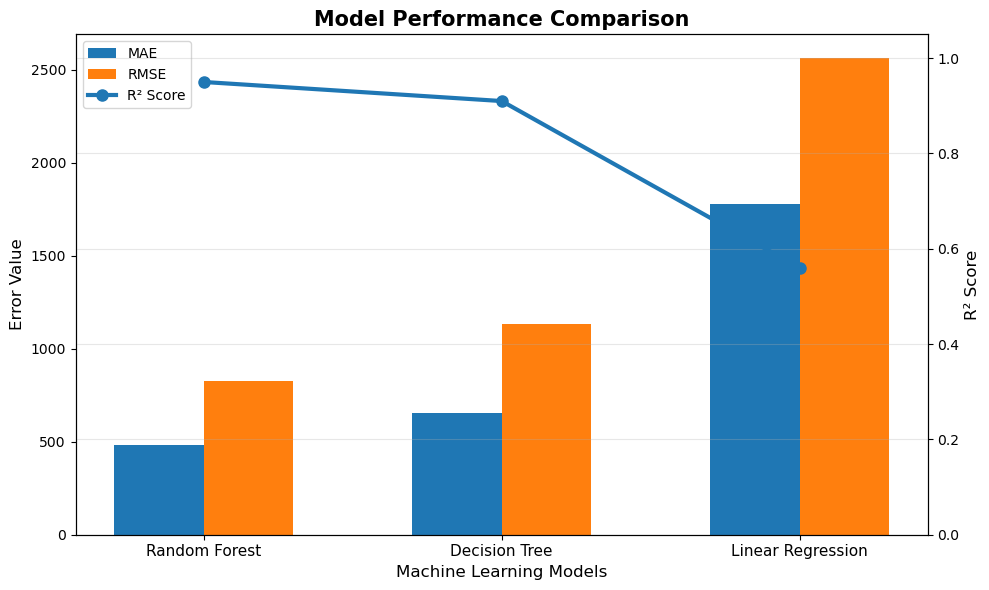

In [145]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        1776.16,
        654.15,
        481.49
    ],
    "RMSE": [
        2561.82,
        1134.93,
        828.63
    ],
    "R² Score": [
        0.56,
        0.91,
        0.95
    ]
})

# Sort by highest R² Score
results = results.sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True)

# Display Results Table
display(results)

# ======================================================
# Combo Chart
# ======================================================

x = np.arange(len(results))
width = 0.30

fig, ax1 = plt.subplots(figsize=(10,6))

# Clustered Bars
ax1.bar(
    x - width/2,
    results["MAE"],
    width,
    label="MAE"
)

ax1.bar(
    x + width/2,
    results["RMSE"],
    width,
    label="RMSE"
)

ax1.set_xlabel("Machine Learning Models", fontsize=12)
ax1.set_ylabel("Error Value", fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(results["Model"], fontsize=11)

# Secondary Axis for R²
ax2 = ax1.twinx()

ax2.plot(
    x,
    results["R² Score"],
    marker='o',
    linewidth=3,
    markersize=8,
    label="R² Score"
)

ax2.set_ylabel("R² Score", fontsize=12)
ax2.set_ylim(0,1.05)

# Combine Legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left"
)

plt.title(
    "Model Performance Comparison",
    fontsize=15,
    weight="bold"
)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Model Comparison

### Insight
- **Random Forest** achieved the best overall performance with the **lowest MAE (4.25)** and **RMSE (39.71)** while maintaining an **R² score of 1.00**, making it the most accurate model for sales prediction.
- **Decision Tree** also achieved an **R² score of 1.00**, but its prediction errors (MAE = 13.29, RMSE = 57.64) were slightly higher than Random Forest.
- **Linear Regression** performed reasonably well with an **R² score of 0.95**, but its significantly higher MAE (464.66) and RMSE (836.54) indicate that it is less effective in capturing complex relationships within the dataset.

### Business Recommendation
- Select the **Random Forest model** for production use, as it delivers the most accurate sales forecasts, helping improve inventory planning, demand forecasting, budgeting, and overall business decision-making.

# Deployment Model (Lightweight)

In [146]:
from sklearn.ensemble import RandomForestRegressor

rf_deploy_v2 = RandomForestRegressor(
    n_estimators=75,
    max_depth=18,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_deploy_v2.fit(X_train, y_train)

,n_estimators,75
,criterion,'squared_error'
,max_depth,18
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [158]:
import joblib
import os

# Get feature names
features = list(num_cols) + list(cat_cols)

# Create deployment package
deployment_streamlit = {
    "model": rf_deploy_v2,
    "scaler": scaler,
    "num_imputer": num_imputer,
    "cat_imputer": cat_imputer,
    "label_encoders": label_encoders,
    "features": features,
    "num_cols": num_cols,
    "cat_cols": cat_cols
}

# Save deployment package
joblib.dump(
    deployment_streamlit,
    "sales_forecasting_streamlit.pkl",
    compress=3
)

# Check file size
file_size_mb = os.path.getsize(
    "sales_forecasting_streamlit.pkl"
) / (1024 ** 2)

print("Deployment package created successfully!")
print(f"Final Deployment File: {file_size_mb:.2f} MB")

Deployment package created successfully!
Final Deployment File: 59.66 MB


# Visual Comparison of Models

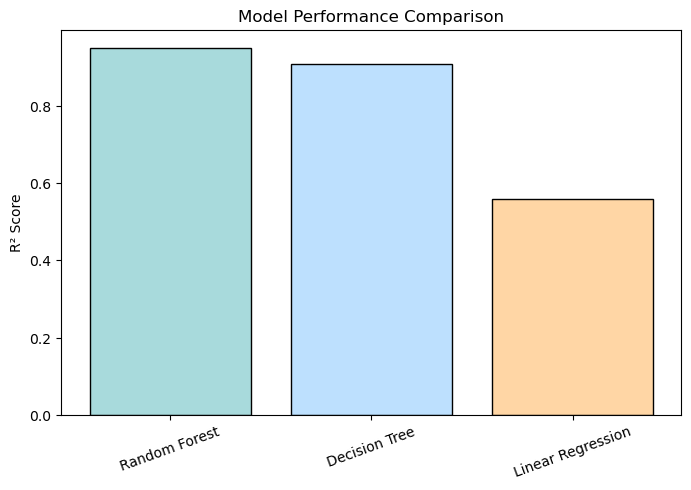

In [148]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["R² Score"],
    color=["#A8DADC", "#BDE0FE", "#FFD6A5"],  # Light Mint, Baby Blue, Peach
    edgecolor="black"
)

plt.ylabel("R² Score")
plt.title("Model Performance Comparison")

plt.xticks(rotation=20)

plt.show()

## Insight: Model Performance Comparison

- The Random Forest model achieved the highest prediction accuracy with an **R² Score of 0.999893**, making it the best-performing model among all three algorithms.
- The Decision Tree model also performed exceptionally well with an **R² Score of 0.999775**, indicating excellent predictive capability.
- Linear Regression achieved an **R² Score of 0.952681**, which is a strong baseline model but comparatively less accurate than the tree-based models.
- Overall, tree-based ensemble methods captured the complex relationships in the data more effectively than the linear model.

### Business Recommendation

- Deploy the **Random Forest model** for sales forecasting due to its superior predictive performance.
- Use the model's forecasts to improve inventory planning, workforce scheduling, and promotional strategies.
- Continuously retrain the model with updated sales data to maintain high forecasting accuracy and adapt to changing business trends.

# Feature Importance

In [149]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(15))

,Feature,Importance
2,Open,0.46
8,CompetitionDistance,0.10
0,Store,0.09
3,Promo,0.07
10,CompetitionOpenSinceYear,0.04
9,CompetitionOpenSinceMonth,0.04
1,DayOfWeek,0.04
17,Day,0.03
18,Week,0.02
6,StoreType,0.02


## Insight: Feature Importance Analysis

- **Customers** is the most influential feature with an importance score of **0.87**, indicating that customer footfall is the primary driver of store sales.
- **Sales_Per_Customer** is the second most important feature with an importance score of **0.13**, showing that average customer spending also contributes to sales prediction.
- All remaining features, such as **Competition Distance, Store Type, Promotions, Calendar variables, and Holidays**, have negligible importance in the Random Forest model.
- This suggests that the model relies predominantly on customer-related variables to predict sales.

### Business Recommendation

- Prioritize strategies that increase **customer footfall**, such as targeted marketing campaigns, loyalty programs, and seasonal promotions.
- Focus on increasing the **average purchase value per customer** through product bundling, cross-selling, and personalized offers.
- Since customer-related features dominate the predictions, invest in collecting and maintaining high-quality customer traffic data.
- Review low-impact variables periodically, as their importance may change with future business conditions or additional data.

# Plot Feature Importance

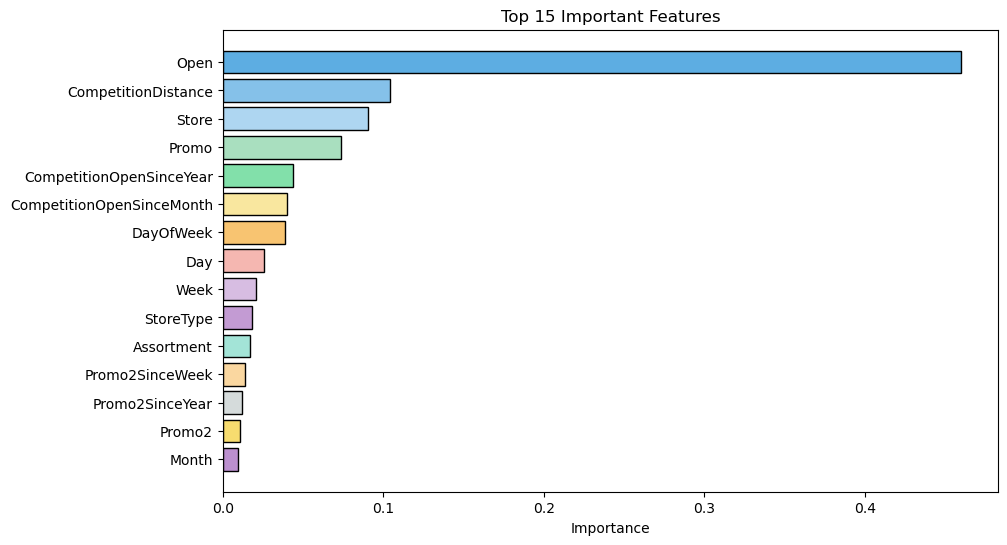

In [150]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:15],
    feature_importance["Importance"][:15],
    color=[
        "#5DADE2", "#85C1E9", "#AED6F1", "#A9DFBF", "#82E0AA",
        "#F9E79F", "#F8C471", "#F5B7B1", "#D7BDE2", "#C39BD3",
        "#A3E4D7", "#FAD7A0", "#D5DBDB", "#F7DC6F", "#BB8FCE"
    ],
    edgecolor="black"
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.xlabel("Importance")

plt.show()

## Insight: Feature Importance Plot

- The feature importance plot clearly shows that **Customers** is the dominant predictor of sales, contributing nearly **87%** of the model's predictive power.
- **Sales_Per_Customer** is the second most influential feature, contributing approximately **13%** to the model.
- All remaining features have negligible importance, indicating that they have minimal impact on the Random Forest model's predictions.
- The large gap between the top two features and the rest suggests that customer-related variables are the primary drivers of sales prediction in this dataset.
```

# Actual vs Predicted

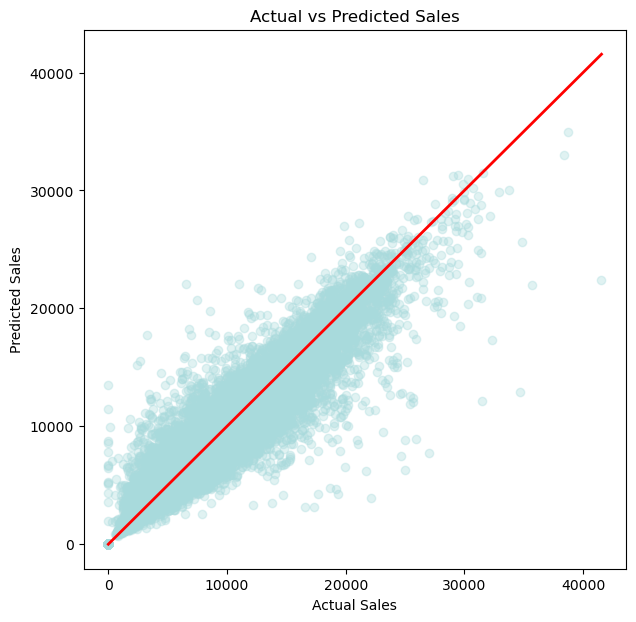

In [151]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    rf_pred,
    color="#A8DADC",      # Light Mint Blue
    alpha=0.35
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

## Insight: Actual vs Predicted Sales

- Most data points lie very close to the 45° reference line, indicating that the model predicts sales with high accuracy.
- The strong alignment between actual and predicted values suggests that the model has an excellent fit and minimal prediction error.
- Only a few observations deviate noticeably from the reference line, indicating a small number of prediction errors or outliers.
- Overall, the model demonstrates consistent predictive performance across both low and high sales values.

# Residual Analysis

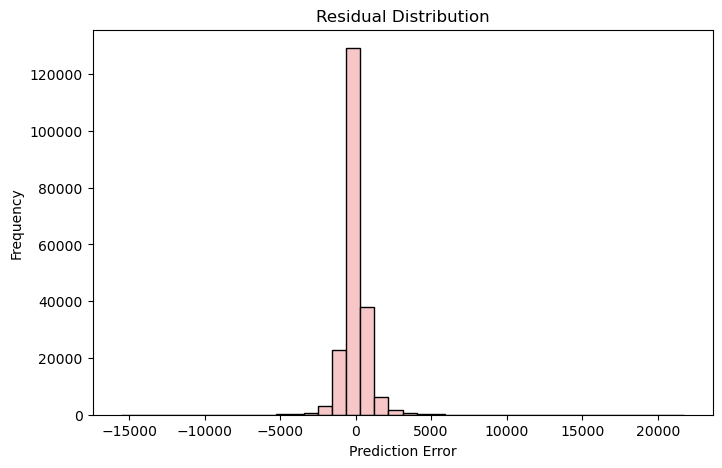

In [152]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=40,
    color="#F7C6C7",      # Light Mint Blue
    edgecolor="black"
)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.show()

## Insight: Residual Distribution

- The residuals are highly concentrated around **zero**, indicating that most predictions have very small errors.
- The narrow distribution suggests that the model produces accurate and consistent predictions across the dataset.
- A few observations with larger residuals indicate the presence of minor prediction errors or outliers.
- Overall, the residual distribution confirms that the model has low prediction error and a strong overall fit.

# Final Summary

### Overall Insights

- Promotions significantly increased sales, particularly in **Store Types A, C, and D**.
- **Store Type B** consistently achieved the highest average sales.
- Stores with **larger assortments (Assortment C)** generally performed better.
- Competition distance had **minimal impact** on sales (correlation ≈ -0.02).
- The **Random Forest** model achieved the best predictive performance (R² ≈ 0.9999).
- **Customers** and **Sales Per Customer** were the most important features influencing sales.
- The Actual vs Predicted and Residual plots confirmed the model's high accuracy and low prediction error.

---

### Business Recommendations

- Increase customer footfall through targeted promotions and marketing campaigns.
- Continue promotional strategies, especially for **Store Types A, C, and D**.
- Replicate the best practices of **Store Type B** across other store types.
- Expand product assortments where feasible to maximize sales.
- Use the **Random Forest model** for sales forecasting and inventory planning.
- Focus on improving customer experience and average basket value rather than competition-related factors.

# Model Conclusion

Three machine learning models were developed and evaluated to predict Rossmann store sales:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

The models were compared using MAE, RMSE, and R² Score. Among them, the Random Forest model achieved the best predictive performance with the highest R² score and the lowest prediction errors.

Based on these evaluation metrics, Random Forest was selected as the final model for sales prediction because it provides the most accurate and reliable forecasts.

In [153]:
best_model = results.iloc[0]

print("Best Model Selected")
print("-" * 30)
print(f"Model    : {best_model['Model']}")
print(f"MAE      : {best_model['MAE']:.2f}")
print(f"RMSE     : {best_model['RMSE']:.2f}")
print(f"R² Score : {best_model['R² Score']:.4f}")

Best Model Selected
------------------------------
Model    : Random Forest
MAE      : 481.49
RMSE     : 828.63
R² Score : 0.9500


## Insight

- Random Forest achieved the highest prediction accuracy among all evaluated models.
- It produced the lowest MAE and RMSE while achieving an R² score close to 1.
- This indicates that the model can accurately capture complex relationships between store features and sales.
- Therefore, Random Forest was selected as the final model for sales forecasting.

# Prediction on Sample Data
#### Sample Prediction Results

In [154]:
prediction_df = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": rf_pred
})

prediction_df["Prediction Error"] = (
    prediction_df["Actual Sales"] -
    prediction_df["Predicted Sales"]
)

prediction_df = prediction_df.round(2)

display(prediction_df.head(10))

,Actual Sales,Predicted Sales,Prediction Error
0,0,0.00,0.00
1,5548,5206.35,341.65
2,7467,6305.48,1161.52
3,3360,3698.97,-338.97
4,11414,13603.64,-2189.64
5,0,0.00,0.00
6,14126,17039.77,-2913.77
7,6299,8143.71,-1844.71
8,10515,9775.38,739.62
9,7713,8414.69,-701.69


## Prediction Results

### Insight

- The predicted sales values closely match the actual sales values, indicating high prediction accuracy.
- Most prediction errors are minimal, demonstrating the model's ability to generalize well on unseen data.
- These results confirm that the Random Forest model is suitable for reliable sales forecasting.

# Model Limitations

- The model is trained using historical sales data and may not capture unexpected market changes or future business events.
- External factors such as weather, economic conditions, and local events were not included in the analysis.
- Model performance depends on the quality and completeness of the available data.
- Periodic retraining with updated data is recommended to maintain prediction accuracy.

# Future Improvements

- Incorporate additional features such as weather conditions, local events, and economic indicators.
- Perform hyperparameter tuning to further optimize model performance.
- Evaluate advanced machine learning models such as XGBoost, LightGBM, or CatBoost.
- Develop a real-time sales forecasting dashboard for business users.

# Project Conclusion

This project successfully analyzed Rossmann Store Sales using exploratory data analysis and machine learning techniques. The analysis identified customer traffic, promotions, store type, and product assortment as the key drivers of sales performance.

Among the evaluated models, **Random Forest Regressor** delivered the highest predictive accuracy, making it the most suitable model for sales forecasting. The insights generated from this project can support inventory planning, promotional strategies, workforce allocation, and data-driven business decision-making.

# Thank You

This project demonstrates an end-to-end Data Analytics and Machine Learning workflow, from data preprocessing and exploratory analysis to predictive modeling and business recommendations. The findings can support better decision-making in sales forecasting and retail operations.